In [1]:
%load_ext autoreload
%autoreload 2

# End-to-End CBIS-DDSM Mammography CAD Pipeline
## Abnormality Localization (Faster R-CNN) & Malignancy Classification (ResNet-50)

This notebook implements the complete end-to-end Computer-Aided Diagnosis (CAD) pipeline for full-field digital mammograms:
1. **Dataset Ingestion & Preprocessing**: Patient-grouped data preparation, 1024x1024 detection transforms, and 256x256 classification transforms.
2. **Model Loading & Checkpoints**: Faster R-CNN (localization) and ResNet-50 (malignancy classification) with fallback to trained weights.
3. **Cascaded Inference**: Full mammogram $\rightarrow$ Abnormality bounding box detection $\rightarrow$ Dynamic ROI cropping $\rightarrow$ Malignancy risk prediction.
4. **Diagnostic Visualization & Clinical Evaluation**: Annotated overlays, risk classification, ROC-AUC, sensitivity, specificity, and mAP metrics.

## 1. Imports & Environment Setup

In [2]:
import os
import sys
from pathlib import Path
import tabulate
try:
    from IPython.display import display
except ImportError:
    display = print

# Math and ML imports
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast
import torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision import transforms

# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Project imports
from util import (
    download_dataset,
    create_dataframes,
    pair_images,
    patient_grouped_split,
    get_model_file_path,
    evaluate_model,
    run_inference,
    min_max_normalize
)
from custom_datasets import (
    CBISDDSM_RCNN_Dataset,
    CBISDDSM_ResNet_Dataset
)

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def get_compute_device() -> torch.device:
    """Select the best supported inference device: CUDA, Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')

    # torch.backends.mps is unavailable in some CPU-only PyTorch builds.
    mps_backend = getattr(torch.backends, 'mps', None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device('mps')

    return torch.device('cpu')

device = get_compute_device()
print(f"Active compute device: {device}")

Active compute device: cuda


## 2. Dataset Ingestion & Image Pairing
Download and verify the CBIS-DDSM dataset, construct metadata dataframes, and pair full mammograms with their corresponding ROI masks and pathology labels.

In [3]:
# 1. Verify / download CBIS-DDSM dataset files
download_dataset()

# 2. Ingest metadata dataframes
dicom_df, full_mammograms_df, roi_masks_df, cropped_df = create_dataframes()

print(f"Total mammogram images: {len(full_mammograms_df)}")
print(f"Total ROI mask entries: {len(roi_masks_df)}")
print(f"Total cropped abnormality entries: {len(cropped_df)}")

# 3. Pair full mammograms with their ROI masks
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

# 4. Integrate pathology annotations (BENIGN vs. MALIGNANT) for stratification and evaluation
mass_df = pd.read_csv('../data/cbis-ddsm/csv/mass_case_description_merged.csv')
mass_df['uid'] = mass_df['image file path'].str.split('/').str[0] + '_' + mass_df['abnormality id'].astype(str)
mass_df['pathology'] = mass_df['pathology'].str.split('_').str[0]

merged_with_path = pd.merge(
    merged_df,
    mass_df[['uid', 'pathology']],
    left_on='PatientID_roi',
    right_on='uid',
    how='left'
)

# Assign image-level pathology (MALIGNANT if any lesion is malignant, else BENIGN)
img_pathology = merged_with_path.groupby('image_path_full')['pathology'].apply(
    lambda x: 'MALIGNANT' if 'MALIGNANT' in x.values else 'BENIGN'
).reset_index()

paired_df = paired_df.merge(img_pathology, on='image_path_full', how='left')
paired_df['PatientID'] = paired_df['PatientID_full']

print()
print(f"Final paired dataframe: {len(paired_df)} mammograms with valid ROI annotations.")
print("Pathology distribution across paired mammograms:")
print(paired_df['pathology'].value_counts())

Path to dataset files: C:\Users\nerfb\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1
Target directory is not empty. Skipping data copy.
Total mammogram images: 2857
Total ROI mask entries: 3247
Total cropped abnormality entries: 3567
Successfully paired 3242 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 2742 image entries.

Final paired dataframe: 2742 mammograms with valid ROI annotations.
Pathology distribution across paired mammograms:
pathology
BENIGN       2011
MALIGNANT     731
Name: count, dtype: int64


## 3. Patient-Grouped Stratified Train/Test Split
To prevent data leakage, all images, views (CC/MLO), and lesions belonging to the same patient (`P_#####`) are grouped into the same split.

In [4]:
# Perform patient-grouped split (80% train, 20% test) on paired mammograms
train_paired_df, test_paired_df = patient_grouped_split(
    paired_df,
    test_size=0.2,
    random_state=SEED,
    verbose=True
)

# Filter cropped dataframe to ensure patient-level separation matching evaluation
cropped_df_filtered = cropped_df[cropped_df['PatientID'].isin(merged_df['PatientID_roi'])].copy()
train_cropped_df, test_cropped_df = patient_grouped_split(
    cropped_df_filtered,
    test_size=0.2,
    random_state=SEED,
    verbose=True
)

Train  2192 rows (79.9%), 1112 patients [BENIGN: 1608, MALIGNANT: 584]
Test    550 rows (20.1%),  281 patients [BENIGN: 403, MALIGNANT: 147]
No patient is shared between any of the 2 splits.
Train  2531 rows (80.0%), 1118 patients [BENIGN: 1480, MALIGNANT: 1051]
Test    633 rows (20.0%),  275 patients [BENIGN: 371, MALIGNANT: 262]
No patient is shared between any of the 2 splits.


## 4. Albumentations Preprocessing Transformations
Define preprocessing pipelines:
- **Detection (Faster R-CNN)**: 1024x1024 aspect-preserving resize with letterbox padding and bounding box tracking.
- **Classification (ResNet-50)**: 256x256 resizing with ImageNet mean/standard deviation normalization.

In [5]:
# Detection transform with bounding box support (Pascal VOC format: [xmin, ymin, xmax, ymax])
detection_transform = A.Compose(
    [
        A.LongestMaxSize(1024),
        A.PadIfNeeded(1024, 1024),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

# Inference transform for full mammograms (without ground-truth bboxes)
detection_inference_transform = A.Compose(
    [
        A.LongestMaxSize(1024),
        A.PadIfNeeded(1024, 1024),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ]
)

# Classification transform for 256x256 cropped patches
classification_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

# Inverse normalization transform for patch visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

## 5. PyTorch Datasets & DataLoaders Setup
Instantiate dataset objects for the test evaluation set and prepare DataLoaders.

In [6]:
def collate_fn(batch):
    """Custom collate function for object detection batches with varying box counts."""
    return tuple(zip(*batch))

# Test dataset and DataLoader for Faster R-CNN detection evaluation
test_detection_dataset = CBISDDSM_RCNN_Dataset(
    dataframe=test_paired_df,
    transform=detection_transform
)

test_detection_loader = DataLoader(
    test_detection_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# Test dataset and DataLoader for ResNet classification evaluation
test_classification_dataset = CBISDDSM_ResNet_Dataset(
    dataframe=test_cropped_df,
    transform=classification_transform
)

test_classification_loader = DataLoader(
    test_classification_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

print(f"Detection evaluation samples: {len(test_detection_dataset)} images")
print(f"Classification evaluation samples: {len(test_classification_dataset)} crops")

Detection evaluation samples: 550 images
Classification evaluation samples: 633 crops


## 6. Preprocessing & Dataset Sanity Verification
Verify tensor dimensions, bounding box targets, and sample annotations on the test evaluation dataset.

Detection image tensor shape: torch.Size([3, 1024, 1024]) (Expected: [3, 1024, 1024])
Detection bounding boxes: torch.Size([1, 4])
Detection labels: tensor([1])
Classification crop tensor shape: torch.Size([3, 256, 256]) (Expected: [3, 256, 256])
Classification label: 2 (MALIGNANT, label_map={'BACKGROUND': 0, 'BENIGN': 1, 'MALIGNANT': 2})


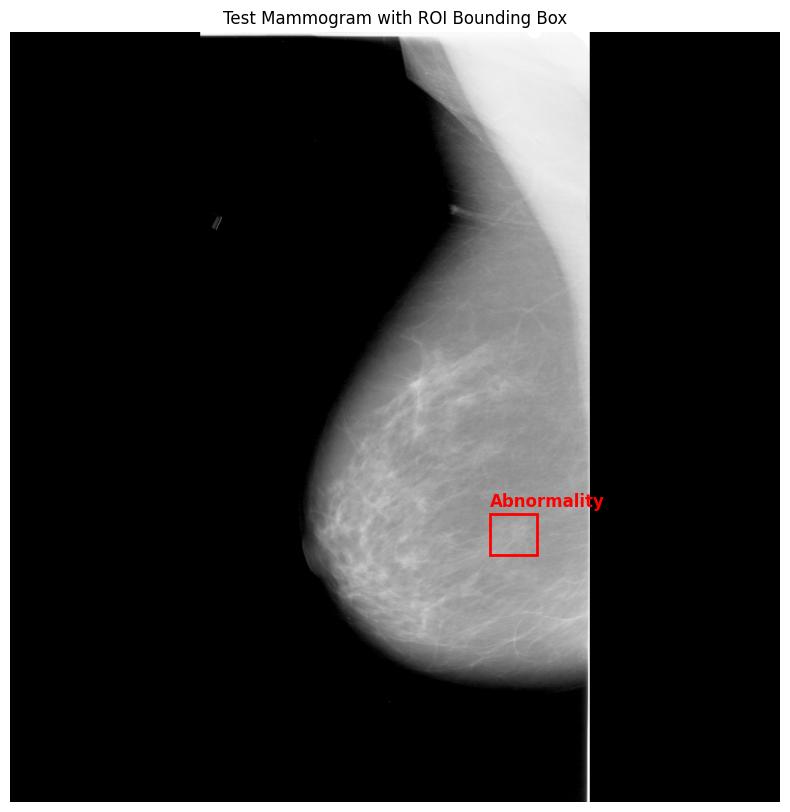

In [7]:
# Verify Faster R-CNN sample shapes
sample_img_tensor, sample_target = test_detection_dataset[0]
print(f"Detection image tensor shape: {sample_img_tensor.shape} (Expected: [3, 1024, 1024])")
print(f"Detection bounding boxes: {sample_target['boxes'].shape}")
print(f"Detection labels: {sample_target['labels']}")

# Verify ResNet sample shapes
sample_crop_tensor, sample_label = test_classification_dataset[0]
label_map_inv = {v: k for k, v in CBISDDSM_ResNet_Dataset.LABEL_MAP.items()}
label_name = label_map_inv.get(int(sample_label), f"CLASS_{sample_label}")
print(f"Classification crop tensor shape: {sample_crop_tensor.shape} (Expected: [3, 256, 256])")
print(f"Classification label: {sample_label} ({label_name}, label_map={CBISDDSM_ResNet_Dataset.LABEL_MAP})")

# Visualize sample annotation from detection dataset
test_detection_dataset.visualize_sample(0, title="Test Mammogram with ROI Bounding Box")

## 7. Model Architecture Definition & Checkpoint Resolution
Instantiate the localization detector (**Faster R-CNN with ResNet-50 FPN**) and malignancy classifier (**ResNet-50**).

Features:
- **Dynamic / Interactive Checkpoint Prompt**: Queries user for custom weights via `get_model_file_path()` with automatic fallback to high-performing completed models in `models/`.
- **Robust State-Dict Unwrapping**: Handles both plain state dicts and wrapped checkpoint dictionaries.
- **Evaluation Mode & Device Assignment**: Configures models for inference on the active CUDA, Apple Silicon MPS, or CPU device selected during setup.

In [18]:
from torchvision.models.detection.anchor_utils import AnchorGenerator
import torchvision.models as models
import torchvision.models.detection as detection
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_rcnn_detector(num_classes: int = 2) -> nn.Module:
    """
    Initializes a Faster R-CNN model with a ResNet-50-FPN backbone adapted for mammogram abnormality localization.

    :param num_classes: Number of detection classes (background + abnormality = 2).
    :return: Configured Faster R-CNN detection model.
    """

    anchor_generator = AnchorGenerator(
        sizes=((16, 32), (32, 64), (64, 128), (128, 256), (256, 512)),
        aspect_ratios=((0.5, 0.75, 1.0, 1.33, 2.0),) * 5
    )
    model = detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=torchvision.models.ResNet50_Weights.DEFAULT,
        trainable_backbone_layers=5,
        rpn_anchor_generator=anchor_generator,
        box_score_thresh=0.05,
        box_nms_thresh=0.5,
        box_detections_per_img=100
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def get_resnet_classifier(num_classes: int = 3) -> nn.Module:
    """
    Initializes a ResNet-50 classifier adapted for multi-class malignancy classification
    (BACKGROUND: 0, BENIGN: 1, MALIGNANT: 2) or legacy binary classification (BENIGN: 0, MALIGNANT: 1).

    :param num_classes: Number of target classes (default 3: BACKGROUND=0, BENIGN=1, MALIGNANT=2).
    :return: Configured ResNet-50 classification model.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

def load_model_weights(model: nn.Module, checkpoint_path: str, device: torch.device) -> nn.Module:
    """
    Loads model weights from a .pth checkpoint file into the given model architecture.
    Robustly handles both plain state dicts and wrapped checkpoint dictionaries.

    :param model: PyTorch model instance.
    :param checkpoint_path: Path to the .pth checkpoint file.
    :param device: Target compute device.
    :return: Model transferred to device and set to evaluation mode.
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        elif 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model' in checkpoint:
            state_dict = checkpoint['model']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

In [19]:
def resolve_checkpoint_path(
    model_name: str,
    completed_dir: str,
    default_filename: str,
    prompt_user: bool = False
) -> str:
    """
    Resolve a checkpoint path, preferring the verified completed checkpoint.

    Interactive selection is opt-in; normal notebook execution is deterministic and
    uses ``default_filename`` (``completed.pth`` for the classifier).
    """
    default_path = os.path.join(completed_dir, default_filename)
    if not os.path.exists(default_path):
        available = [f for f in os.listdir(completed_dir) if f.endswith('.pth')]
        if available:
            default_path = os.path.join(completed_dir, sorted(available)[-1])

    selected_path = None
    if prompt_user:
        try:
            prompt = f"Load custom {model_name} checkpoint from {completed_dir}? (y/n): "
            selected_path = get_model_file_path(prompt, completed_dir, loop=False)
        except Exception as e:
            print(f"Interactive dialog unavailable ({e}). Falling back to default checkpoint.")

    if selected_path and os.path.isfile(selected_path):
        print(f"[{model_name}] Using selected checkpoint: {selected_path}")
        return selected_path

    print(f"[{model_name}] Using verified default checkpoint: {default_path}")
    return default_path

# Resolve paths for Faster R-CNN and ResNet-50 models
rcnn_completed_dir = '../models/Faster_RCNN/completed'
resnet_completed_dir = '../models/Resnet/completed'

# Keep the standard execution path deterministic. Custom checkpoints remain
# available by calling resolve_checkpoint_path(..., prompt_user=True) explicitly.
rcnn_checkpoint_path = resolve_checkpoint_path(
    model_name="Faster R-CNN Detector",
    completed_dir=rcnn_completed_dir,
    default_filename="0.6392_mAP.pth",
    prompt_user=True
)

resnet_checkpoint_path = resolve_checkpoint_path(
    model_name="ResNet-50 Classifier",
    completed_dir=resnet_completed_dir,
    default_filename="completed.pth",
    prompt_user=True
)

# Instantiate and load models onto compute device in evaluation mode
print("\n--- Instantiating & Loading Models ---")
rcnn_model = get_rcnn_detector(num_classes=2)
rcnn_model = load_model_weights(rcnn_model, rcnn_checkpoint_path, device)
print(f"Faster R-CNN Detector loaded successfully onto {device} in eval mode.")

resnet_model = get_resnet_classifier(num_classes=3)
resnet_model = load_model_weights(resnet_model, resnet_checkpoint_path, device)
print(f"ResNet-50 Classifier loaded successfully onto {device} in eval mode.")

[Faster R-CNN Detector] Using selected checkpoint: C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Faster_RCNN/completed/calcifications/0.3912_mAP.pth
[ResNet-50 Classifier] Using selected checkpoint: C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Resnet/completed/calcifications/0.64-0.69-0.89_recalls.pth

--- Instantiating & Loading Models ---
Faster R-CNN Detector loaded successfully onto cuda in eval mode.
ResNet-50 Classifier loaded successfully onto cuda in eval mode.


## 8. Model Loading & Inference Sanity Verification
Validate that the loaded Faster R-CNN detector and ResNet-50 classifier execute forward inference passes correctly on test samples without error.

In [20]:
# 1. Sanity check: Faster R-CNN detection pass on sample test image
sample_img_tensor, sample_target = test_detection_dataset[0]

with torch.no_grad():
    detection_predictions = rcnn_model([sample_img_tensor.to(device)])

pred_boxes = detection_predictions[0]['boxes'].cpu().numpy()
pred_scores = detection_predictions[0]['scores'].cpu().numpy()
pred_labels = detection_predictions[0]['labels'].cpu().numpy()

print("Faster R-CNN Test Forward Pass:")
print(f"  Input image shape: {list(sample_img_tensor.shape)}")
print(f"  Total candidate detections: {len(pred_boxes)}")
if len(pred_scores) > 0:
    print(f"  Top detection score: {pred_scores[0]:.4f} at box {pred_boxes[0].astype(int).tolist()}")

# 2. Sanity check: ResNet-50 classification pass on sample cropped abnormality patch
sample_crop_tensor, sample_label = test_classification_dataset[0]

with torch.no_grad():
    logits = resnet_model(sample_crop_tensor.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

label_map_inv = {v: k for k, v in CBISDDSM_ResNet_Dataset.LABEL_MAP.items()}
gt_class = label_map_inv.get(int(sample_label), f"CLASS_{sample_label}")

if len(probs) == 3:
    class_names = ["BACKGROUND", "BENIGN", "MALIGNANT"]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    prob_str = f"P(Background)={probs[0]:.4f}, P(Benign)={probs[1]:.4f}, P(Malignant)={probs[2]:.4f}"
elif len(probs) == 2:
    class_names = ["BENIGN", "MALIGNANT"]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    prob_str = f"P(Benign)={probs[0]:.4f}, P(Malignant)={probs[1]:.4f}"
else:
    pred_idx = int(np.argmax(probs))
    pred_class = f"CLASS_{pred_idx}"
    prob_str = f"probs={probs.tolist()}"

print(f"\nResNet-50 Test Forward Pass:")
print(f"  Input patch shape: {list(sample_crop_tensor.shape)}")
print(f"  Ground Truth: {gt_class} (label={sample_label})")
print(f"  Predicted Class: {pred_class} ({prob_str})")
print("\nModel initialization and weight resolution verified successfully!")

Faster R-CNN Test Forward Pass:
  Input image shape: [3, 1024, 1024]
  Total candidate detections: 8
  Top detection score: 0.5614 at box [518, 597, 583, 665]

ResNet-50 Test Forward Pass:
  Input patch shape: [3, 256, 256]
  Ground Truth: MALIGNANT (label=2)
  Predicted Class: MALIGNANT (P(Background)=0.0067, P(Benign)=0.3641, P(Malignant)=0.6292)

Model initialization and weight resolution verified successfully!


## 9. Cascaded Detection & Classification Inference Engine
Implement the complete end-to-end inference chain:
1. **Full-Field Mammogram Preprocessing (`preprocess_mammogram`)**: Standardizes input image to 1024x1024 letterbox tensor with scaling/padding metadata.
2. **Abnormality Detection (`detect_abnormalities`)**: Faster R-CNN forward pass with configurable confidence threshold ($	au_{det} \approx 0.3-0.5$) and Non-Maximum Suppression (NMS).
3. **Coordinate Transformation (`map_box_to_original`)**: Inverts detector coordinates back into original high-resolution pixel space.
4. **Dynamic ROI Extraction (`crop_and_preprocess_rois`)**: Crops detected lesion patches from original image with adaptive margin padding and strict boundary clamping.
5. **Malignancy Classification (`classify_abnormalities`)**: ResNet-50 forward pass on 256x256 normalized patches to predict $P(	ext{MALIGNANT})$ and discrete diagnostic labels.
6. **Unified Pipeline Coordinator (`run_full_pipeline`)**: Orchestrates the cascaded inference chain and produces structured `PipelineOutput` records.

In [21]:
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

@dataclass
class DetectionResult:
    """Encapsulates localization and classification outputs for a single detected lesion."""
    box: list  # [xmin, ymin, xmax, ymax] in original high-resolution pixel space
    detection_score: float  # Abnormality localization confidence
    pathology: str  # 'BACKGROUND', 'BENIGN', or 'MALIGNANT'
    malignancy_prob: float  # Predicted probability P(MALIGNANT)
    crop_tensor: Optional[torch.Tensor] = None  # [3, 256, 256] preprocessed patch tensor
    box_det: Optional[list] = None  # [xmin, ymin, xmax, ymax] in 1024x1024 detector space
    background_prob: float = 0.0  # Predicted probability P(BACKGROUND)
    benign_prob: float = 0.0  # Predicted probability P(BENIGN)
    class_probs: Optional[list] = None  # Full multi-class probability breakdown

@dataclass
class PipelineOutput:
    """Encapsulates end-to-end diagnostic results for a full mammogram image."""
    image_path: str
    original_image: np.ndarray
    detections: List[DetectionResult]
    has_malignancy: bool
    max_malignancy_prob: float
    metadata: dict = field(default_factory=dict)

def preprocess_mammogram(
    image_input: str | Path | np.ndarray,
    transform: Optional[A.Compose] = None
) -> Tuple[np.ndarray, torch.Tensor, dict]:
    """
    Loads and preprocesses a raw full-field mammogram for Faster R-CNN abnormality detection.

    :param image_input: File path to mammogram image or RGB/BGR numpy array.
    :param transform: Albumentations transformation pipeline (defaults to detection_inference_transform).
    :return: Tuple of (original_rgb_image, preprocessed_tensor, scaling_metadata).
    """
    if isinstance(image_input, (str, Path)):
        if not os.path.exists(str(image_input)):
            raise FileNotFoundError(f"Mammogram image file not found: {image_input}")
        img_bgr = cv2.imread(str(image_input))
        if img_bgr is None:
            raise ValueError(f"Failed to read image at: {image_input}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    elif isinstance(image_input, np.ndarray):
        if image_input.ndim == 2:
            img_rgb = cv2.cvtColor(image_input, cv2.COLOR_GRAY2RGB)
        elif image_input.ndim == 3 and image_input.shape[2] == 3:
            img_rgb = image_input.copy()
        else:
            raise ValueError(f"Unsupported numpy array shape: {image_input.shape}")
    else:
        raise TypeError(f"Unsupported image input type: {type(image_input)}")

    h_orig, w_orig = img_rgb.shape[:2]
    max_dim = max(h_orig, w_orig)
    scale = 1024.0 / max_dim
    scaled_h = int(round(h_orig * scale))
    scaled_w = int(round(w_orig * scale))
    pad_top = (1024 - scaled_h) // 2
    pad_left = (1024 - scaled_w) // 2

    meta = {
        'h_orig': h_orig,
        'w_orig': w_orig,
        'scale': scale,
        'scaled_h': scaled_h,
        'scaled_w': scaled_w,
        'pad_top': pad_top,
        'pad_left': pad_left
    }

    if transform is None:
        transform = detection_inference_transform

    transformed = transform(image=img_rgb)
    img_tensor = transformed['image']

    return img_rgb, img_tensor, meta

def map_box_to_original(box_det: list | np.ndarray, meta: dict) -> list:
    """
    Map detector-space coordinates into original image space and clamp them.

    Sorting each axis after clamping keeps malformed/reversed detector boxes from
    producing negative-area crops downstream.
    """
    xmin_det, ymin_det, xmax_det, ymax_det = [float(value) for value in box_det]
    scale = float(meta['scale'])
    pad_top = float(meta['pad_top'])
    pad_left = float(meta['pad_left'])
    w_orig = int(meta['w_orig'])
    h_orig = int(meta['h_orig'])

    x1, x2 = sorted(((xmin_det - pad_left) / scale, (xmax_det - pad_left) / scale))
    y1, y2 = sorted(((ymin_det - pad_top) / scale, (ymax_det - pad_top) / scale))

    return [
        float(np.clip(x1, 0, w_orig)),
        float(np.clip(y1, 0, h_orig)),
        float(np.clip(x2, 0, w_orig)),
        float(np.clip(y2, 0, h_orig))
    ]

def detect_abnormalities(
    model: nn.Module,
    image_tensor: torch.Tensor,
    device: torch.device,
    det_thresh: float = 0.4,
    nms_thresh: Optional[float] = 0.3
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Runs Faster R-CNN detection pass on a single mammogram tensor, filtering by confidence score and applying NMS.

    :param model: Faster R-CNN detection model.
    :param image_tensor: Preprocessed tensor of shape [3, 1024, 1024].
    :param device: Compute device.
    :param det_thresh: Confidence threshold for candidate detection.
    :param nms_thresh: Non-maximum suppression IoU threshold.
    :return: Tuple of (filtered_boxes_1024, filtered_scores, filtered_labels).
    """
    model.eval()
    if image_tensor.ndim == 3:
        input_tensors = [image_tensor.to(device)]
    elif image_tensor.ndim == 4:
        input_tensors = [image_tensor[0].to(device)]
    else:
        raise ValueError(f"Invalid tensor dimensions: {image_tensor.shape}")

    with torch.no_grad():
        preds = model(input_tensors)[0]

    boxes = preds['boxes']
    scores = preds['scores']
    labels = preds['labels']

    keep_mask = scores >= det_thresh
    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    labels = labels[keep_mask]

    if len(boxes) > 0 and nms_thresh is not None:
        keep_indices = torchvision.ops.nms(boxes, scores, nms_thresh)
        boxes = boxes[keep_indices]
        scores = scores[keep_indices]
        labels = labels[keep_indices]

    return boxes.cpu().numpy(), scores.cpu().numpy(), labels.cpu().numpy()

def crop_and_preprocess_rois(
    original_image: np.ndarray,
    boxes_orig: list | np.ndarray,
    transform: Optional[A.Compose] = None,
    pad_ratio: float = 0.05,
    return_indices: bool = False
) -> List[Tuple[np.ndarray, torch.Tensor, list]]:
    """
    Crop detected regions with adaptive padding and normalize each crop before the
    classification transform.

    Invalid boxes are skipped safely. With ``return_indices=True`` an internal
    fourth tuple value identifies the source detector box, allowing callers to
    keep scores and coordinates aligned when a crop is skipped.
    """
    if transform is None:
        transform = classification_transform

    if original_image.ndim not in (2, 3) or original_image.shape[0] == 0 or original_image.shape[1] == 0:
        raise ValueError(f"original_image must be a non-empty image array, got shape {original_image.shape}")

    h_img, w_img = original_image.shape[:2]
    pad_ratio = float(pad_ratio)
    if not np.isfinite(pad_ratio):
        pad_ratio = 0.0
    pad_ratio = max(0.0, pad_ratio)
    extracted = []

    for source_index, box in enumerate(boxes_orig):
        coords = np.asarray(box, dtype=np.float64).reshape(-1)
        if coords.size != 4 or not np.all(np.isfinite(coords)):
            continue

        xmin, ymin, xmax, ymax = coords.tolist()
        xmin, xmax = sorted((xmin, xmax))
        ymin, ymax = sorted((ymin, ymax))
        xmin = float(np.clip(xmin, 0, w_img))
        xmax = float(np.clip(xmax, 0, w_img))
        ymin = float(np.clip(ymin, 0, h_img))
        ymax = float(np.clip(ymax, 0, h_img))

        bw = max(1.0, xmax - xmin)
        bh = max(1.0, ymax - ymin)
        pad_w = bw * pad_ratio
        pad_h = bh * pad_ratio

        c_xmin = int(np.clip(np.floor(xmin - pad_w), 0, w_img - 1))
        c_ymin = int(np.clip(np.floor(ymin - pad_h), 0, h_img - 1))
        c_xmax = int(np.clip(np.ceil(xmax + pad_w), 1, w_img))
        c_ymax = int(np.clip(np.ceil(ymax + pad_h), 1, h_img))

        # A clamped point at an image boundary still yields a valid one-pixel crop.
        if c_xmax <= c_xmin:
            c_xmin = min(max(c_xmin, 0), w_img - 1)
            c_xmax = c_xmin + 1
        if c_ymax <= c_ymin:
            c_ymin = min(max(c_ymin, 0), h_img - 1)
            c_ymax = c_ymin + 1

        patch = original_image[c_ymin:c_ymax, c_xmin:c_xmax]
        if patch.size == 0 or patch.shape[0] == 0 or patch.shape[1] == 0:
            continue

        # Match the normalized training distribution before Resize/ImageNet normalization.
        norm_patch = min_max_normalize(patch)
        transformed = transform(image=norm_patch)
        patch_tensor = transformed['image']
        result = (norm_patch, patch_tensor, [c_xmin, c_ymin, c_xmax, c_ymax])
        extracted.append((*result, source_index) if return_indices else result)

    return extracted

def classify_abnormalities(
    model: nn.Module,
    patch_tensors: List[torch.Tensor] | torch.Tensor,
    device: torch.device,
    cls_thresh: float = 0.5
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Run the 3-class classifier and return malignancy probabilities, all class
    probabilities, and labels in BACKGROUND/BENIGN/MALIGNANT order.
    """
    if len(patch_tensors) == 0:
        return np.array([]), np.empty((0, 3)), []

    model.eval()
    batch = torch.stack(patch_tensors).to(device) if isinstance(patch_tensors, list) else patch_tensors.to(device)

    with torch.no_grad():
        logits = model(batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    num_classes = probs.shape[1]
    if num_classes == 3:
        # Class indexing: 0 = BACKGROUND, 1 = BENIGN, 2 = MALIGNANT.
        mal_probs = probs[:, 2]
        labels = [
            "MALIGNANT" if p_mal >= cls_thresh else ("BACKGROUND" if row[0] > row[1] else "BENIGN")
            for p_mal, row in zip(mal_probs, probs)
        ]
    elif num_classes == 2:
        # Legacy class indexing: 0 = BENIGN, 1 = MALIGNANT.
        mal_probs = probs[:, 1]
        labels = ["MALIGNANT" if p >= cls_thresh else "BENIGN" for p in mal_probs]
    else:
        raise ValueError(f"Unexpected number of classifier output classes: {num_classes}")

    return mal_probs, probs, labels

def run_full_pipeline(
    image_input: str | Path | np.ndarray,
    rcnn_model: nn.Module,
    resnet_model: nn.Module,
    device: torch.device,
    det_thresh: float = 0.4,
    nms_thresh: Optional[float] = 0.3,
    cls_thresh: float = 0.5,
    pad_ratio: float = 0.05
) -> PipelineOutput:
    """Execute cascaded detection, normalized ROI classification, and reporting."""
    image_path = str(image_input) if isinstance(image_input, (str, Path)) else "in_memory_array"
    orig_img, img_tensor, meta = preprocess_mammogram(image_input)

    det_boxes, det_scores, det_labels = detect_abnormalities(
        model=rcnn_model, image_tensor=img_tensor, device=device,
        det_thresh=det_thresh, nms_thresh=nms_thresh
    )

    if len(det_boxes) == 0:
        return PipelineOutput(image_path=image_path, original_image=orig_img, detections=[],
                              has_malignancy=False, max_malignancy_prob=0.0, metadata=meta)

    boxes_orig = [map_box_to_original(b, meta) for b in det_boxes]
    cropped_data = crop_and_preprocess_rois(
        original_image=orig_img, boxes_orig=boxes_orig, pad_ratio=pad_ratio, return_indices=True
    )
    if len(cropped_data) == 0:
        return PipelineOutput(image_path=image_path, original_image=orig_img, detections=[],
                              has_malignancy=False, max_malignancy_prob=0.0, metadata=meta)

    patch_tensors = [item[1] for item in cropped_data]
    mal_probs, all_probs, path_labels = classify_abnormalities(
        model=resnet_model, patch_tensors=patch_tensors, device=device, cls_thresh=cls_thresh
    )

    detections: List[DetectionResult] = []
    for i, item in enumerate(cropped_data):
        source_index = item[3]
        p_row = all_probs[i]
        if len(p_row) == 3:
            bg_p, ben_p, mal_p = (float(p_row[0]), float(p_row[1]), float(p_row[2]))
        elif len(p_row) == 2:
            bg_p, ben_p, mal_p = (0.0, float(p_row[0]), float(p_row[1]))
        else:
            bg_p, ben_p, mal_p = (0.0, 0.0, float(mal_probs[i]))

        detections.append(DetectionResult(
            box=boxes_orig[source_index],
            detection_score=float(det_scores[source_index]),
            pathology=path_labels[i],
            malignancy_prob=mal_p,
            crop_tensor=patch_tensors[i],
            box_det=det_boxes[source_index].tolist(),
            background_prob=bg_p,
            benign_prob=ben_p,
            class_probs=p_row.tolist()
        ))

    max_p_mal = float(np.max(mal_probs)) if len(mal_probs) > 0 else 0.0
    return PipelineOutput(
        image_path=image_path, original_image=orig_img, detections=detections,
        has_malignancy=any(d.pathology == "MALIGNANT" for d in detections),
        max_malignancy_prob=max_p_mal, metadata=meta
    )

## 10. Cascaded Inference Validation & Multi-Case Execution
Validate the complete pipeline on test mammogram cases:
- Evaluates localization coordinates and ResNet-50 malignancy probabilities.
- Verifies dynamic cropping and safe coordinate bounds.
- Confirms graceful handling of cases with zero detections above threshold.

In [12]:
# Focused cascaded inference sanity check (kept intentionally separate from batch evaluation).
sample_test_entry = test_paired_df.iloc[0]
sample_result = run_full_pipeline(
    image_input=sample_test_entry['image_path_full'],
    rcnn_model=rcnn_model,
    resnet_model=resnet_model,
    device=device,
    det_thresh=0.4,
    nms_thresh=0.3,
    cls_thresh=0.5
)

print(f"Ground truth: {sample_test_entry['pathology']}")
print(f"Detections: {len(sample_result.detections)}")
for idx, det in enumerate(sample_result.detections, 1):
    print(
        f"  #{idx}: {det.pathology} | P(BACKGROUND)={det.background_prob:.4f} | "
        f"P(BENIGN)={det.benign_prob:.4f} | P(MALIGNANT)={det.malignancy_prob:.4f}"
    )

if sample_result.detections:
    top_detection = max(sample_result.detections, key=lambda det: det.detection_score)
    assert top_detection.pathology in {'BACKGROUND', 'BENIGN', 'MALIGNANT'}
    assert top_detection.class_probs is not None and len(top_detection.class_probs) == 3
    assert abs(sum(top_detection.class_probs) - 1.0) < 1e-5

empty_result = run_full_pipeline(
    image_input=sample_test_entry['image_path_full'],
    rcnn_model=rcnn_model,
    resnet_model=resnet_model,
    device=device,
    det_thresh=0.999
)
assert len(empty_result.detections) == 0
assert empty_result.has_malignancy is False
assert empty_result.max_malignancy_prob == 0.0
print("Focused cascaded inference and zero-detection checks passed.")

Ground truth: BENIGN
Detections: 0
Focused cascaded inference and zero-detection checks passed.


## 11. Clinical Diagnostic Visualization & Case Reporting
Implement rich visualization routines to render full-field mammograms alongside detected abnormality overlays and lesion-level localization error tracking:
- **Color-Coded Bounding Boxes**: Coral/Red (`#EF476F`) for detected lesions classified as `MALIGNANT`; Emerald Green (`#06D6A0`) for `BENIGN`; Slate Blue (`#118AB2`) for `BACKGROUND` (normal fibro-glandular parenchyma / detector false alarms).
- **Ground-Truth Comparison & Error Tracking**: Dashed gold/yellow rectangles for matched ground-truth annotations and orange-red rectangles for missed lesions, providing direct spatial validation.
- **Candidate Localization Categorization**: Distinct badges differentiating matched lesions (`[MATCHED TP]`) from extraneous false alarms (`[EXTRA FP]`), with explicit display of both malignancy and background probabilities.
- **Abnormality Localization Header & Overlay**: Display exact counts of matched, missed, and extra abnormalities on the viewport alongside multi-class risk status.
- **Lesion Crop Panels**: Side-by-side high-resolution previews of extracted 256x256 abnormality crops with individual confidence, 3-class risk assessment, and match status metrics.
- **Tabular Case Reporting**: Structured diagnostic summary tables detailing lesion coordinates, detection confidence, 3-class probability profiles (Malignancy, Background, Benign), stratified risk tiers (`High Risk (Malignant)`, `Moderate / Suspicious`, `Low / Benign`, `Low / Background Tissue`), and match status against ground truth.

In [22]:
def calculate_box_iou(boxA: list | np.ndarray, boxB: list | np.ndarray) -> float:
    """
    Computes Intersection over Union (IoU) between two bounding boxes [xmin, ymin, xmax, ymax].
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_area = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = max(0.0, (boxA[2] - boxA[0]) * (boxA[3] - boxA[1]))
    areaB = max(0.0, (boxB[2] - boxB[0]) * (boxB[3] - boxB[1]))

    union = areaA + areaB - inter_area
    return float(inter_area / union) if union > 0 else 0.0


def match_boxes(
    pred_boxes: List[List[float]],
    gt_boxes: List[List[float]],
    iou_thresh: float = 0.25,
    pred_labels: Optional[List[str]] = None
) -> Tuple[int, int, int, List[int], List[int]]:
    """
    Performs greedy 1-to-1 IoU matching between predicted and ground-truth bounding boxes.
    When pred_labels is provided, only unmatched detections that are predicted as lesions
    ('BENIGN' or 'MALIGNANT') are tallied as extra predictions (false alarms). Detections
    predicted as 'BACKGROUND' are filtered out and not counted as extra predictions.
    When pred_labels is None, all unmatched detections are counted as extra predictions.

    Returns: (matched_count, missed_count, extra_count, matched_gt_indices, matched_pred_indices)
    """
    if len(gt_boxes) == 0:
        if pred_labels is not None:
            extra_preds = [p for p in range(len(pred_boxes)) if pred_labels[p] in ('BENIGN', 'MALIGNANT')]
            return 0, 0, len(extra_preds), [], []
        return 0, 0, len(pred_boxes), [], []
    if len(pred_boxes) == 0:
        return 0, len(gt_boxes), 0, [], []

    matched_gt = set()
    matched_pred = set()

    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)), dtype=float)
    for p_idx, pbox in enumerate(pred_boxes):
        for g_idx, gbox in enumerate(gt_boxes):
            iou_matrix[p_idx, g_idx] = calculate_box_iou(pbox, gbox)

    while True:
        max_iou = np.max(iou_matrix) if iou_matrix.size > 0 else 0.0
        if max_iou < iou_thresh:
            break
        p_idx, g_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
        matched_pred.add(int(p_idx))
        matched_gt.add(int(g_idx))
        iou_matrix[p_idx, :] = -1.0
        iou_matrix[:, g_idx] = -1.0

    matched_count = len(matched_gt)
    missed_count = len(gt_boxes) - matched_count

    if pred_labels is not None:
        extra_pred_list = [
            p for p in range(len(pred_boxes))
            if p not in matched_pred and pred_labels[p] in ('BENIGN', 'MALIGNANT')
        ]
        extra_count = len(extra_pred_list)
    else:
        extra_pred_list = [p for p in range(len(pred_boxes)) if p not in matched_pred]
        extra_count = len(pred_boxes) - matched_count

    return matched_count, missed_count, extra_count, sorted(list(matched_gt)), sorted(list(matched_pred))


def match_abnormalities(
    gt_boxes: List[List[float]],
    pred_boxes: List[List[float]],
    iou_thresh: float = 0.25,
    pred_labels: Optional[List[str]] = None
) -> Tuple[List[int], List[int], List[int]]:
    """
    Matches predicted boxes to ground truth boxes using greedy IoU matching.
    Returns: (matched_gt_indices, missed_gt_indices, extra_pred_indices)
    """
    matched_count, missed_count, extra_count, matched_gt, matched_pred = match_boxes(
        pred_boxes, gt_boxes, iou_thresh=iou_thresh, pred_labels=pred_labels
    )
    missed_gt = [g for g in range(len(gt_boxes)) if g not in matched_gt]
    if pred_labels is not None:
        extra_pred = [
            p for p in range(len(pred_boxes))
            if p not in matched_pred and pred_labels[p] in ('BENIGN', 'MALIGNANT')
        ]
    else:
        extra_pred = [p for p in range(len(pred_boxes)) if p not in matched_pred]
    return matched_gt, missed_gt, extra_pred


def extract_ground_truth_boxes(
    row: pd.Series,
    img_shape: Optional[Tuple[int, int]] = None
) -> List[List[float]]:
    """
    Extracts ground-truth bounding box coordinates [xmin, ymin, xmax, ymax] from ROI mask paths.
    """
    boxes = []
    roi_paths = row.get('image_path_roi', [])
    if isinstance(roi_paths, str):
        roi_paths = [roi_paths]

    for r_path in roi_paths:
        if not os.path.exists(r_path):
            continue
        mask = cv2.imread(r_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        if img_shape is not None and (mask.shape[0] != img_shape[0] or mask.shape[1] != img_shape[1]):
            mask = cv2.resize(mask, (img_shape[1], img_shape[0]), interpolation=cv2.INTER_NEAREST)
        pos = np.where(mask > 0)
        if len(pos[0]) > 0:
            xmin, xmax = float(np.min(pos[1])), float(np.max(pos[1]))
            ymin, ymax = float(np.min(pos[0])), float(np.max(pos[0]))
            boxes.append([xmin, ymin, xmax, ymax])
    return boxes


def visualize_pipeline_prediction(
    result: PipelineOutput,
    gt_boxes: Optional[List[List[float]]] = None,
    gt_pathology: Optional[str] = None,
    title: Optional[str] = None,
    show_crops: bool = True,
    figsize: Tuple[int, int] = (14, 10),
    iou_thresh: float = 0.25
) -> plt.Figure:
    """
    Renders the full mammogram with color-coded detection overlays and optional cropped ROI panels.
    Cross-references detections with ground-truth lesion boxes to visualize matched, missed, and extra abnormalities.
    Candidate detections predicted as BACKGROUND are filtered out from visual overlays and crop panels,
    displaying an explicit informational message indicating filtered normal tissue.

    :param result: PipelineOutput dataclass from run_full_pipeline.
    :param gt_boxes: Optional list of ground truth bounding boxes in original coordinate space.
    :param gt_pathology: Optional ground-truth pathology ('BENIGN' or 'MALIGNANT').
    :param title: Optional plot title.
    :param show_crops: Whether to show extracted ROI patch crops in subplots.
    :param figsize: Matplotlib figure dimensions.
    :param iou_thresh: IoU threshold for matching candidate detections to ground-truth lesions.
    """
    all_dets = result.detections
    active_dets = [(idx, det) for idx, det in enumerate(all_dets) if det.pathology in ('BENIGN', 'MALIGNANT')]
    bg_dets = [(idx, det) for idx, det in enumerate(all_dets) if det.pathology == 'BACKGROUND']
    num_active = len(active_dets)
    num_bg = len(bg_dets)
    has_crops = show_crops and num_active > 0

    if has_crops:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(num_active, 3, width_ratios=[2.2, 1, 0.05])
        ax_main = fig.add_subplot(gs[:, 0])
    else:
        fig, ax_main = plt.subplots(1, 1, figsize=figsize)

    # 1. Display full mammogram
    ax_main.imshow(result.original_image, cmap='gray')

    pred_boxes = [d.box for d in all_dets]
    pred_labels = [d.pathology for d in all_dets]
    matched_gt_set = set()
    matched_pred_set = set()
    matched_count, missed_count, extra_count = 0, (len(gt_boxes) if gt_boxes else 0), num_active

    if gt_boxes is not None:
        matched_count, missed_count, extra_count, matched_gt_list, matched_pred_list = match_boxes(
            pred_boxes, gt_boxes, iou_thresh=iou_thresh, pred_labels=pred_labels
        )
        matched_gt_set = set(matched_gt_list)
        matched_pred_set = set(matched_pred_list)

    # 2. Draw ground truth bounding boxes if available
    if gt_boxes:
        for g_idx, gbox in enumerate(gt_boxes):
            gw = max(1.0, gbox[2] - gbox[0])
            gh = max(1.0, gbox[3] - gbox[1])
            is_matched_gt = g_idx in matched_gt_set

            if is_matched_gt:
                edge_color = '#FFD166'
                border_style = '--'
                gt_tag = "MATCHED"
            else:
                edge_color = '#FF5722'
                border_style = '--'
                gt_tag = "MISSED"

            rect = patches.Rectangle(
                (gbox[0], gbox[1]), gw, gh,
                linewidth=2.5, edgecolor=edge_color, facecolor='none', linestyle=border_style
            )
            ax_main.add_patch(rect)

            base_gt_label = f"GT: {gt_pathology}" if gt_pathology else f"GT #{g_idx+1}"
            gt_text = f"{base_gt_label} [{gt_tag}]"
            ax_main.text(
                gbox[0], max(10.0, gbox[1] - 25),
                gt_text, color=edge_color, fontsize=9.5, weight='bold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='#1A1A1A', edgecolor=edge_color, alpha=0.85)
            )

    # Helper function for 3-class color mapping
    def get_pathology_color(pathology: str) -> str:
        if pathology == 'MALIGNANT':
            return '#EF476F'
        elif pathology == 'BENIGN':
            return '#06D6A0'
        elif pathology == 'BACKGROUND':
            return '#118AB2'
        return '#06D6A0'

    # 3. Draw predicted bounding boxes (Active Lesion detections only)
    if num_active > 0:
        for orig_idx, det in active_dets:
            color = get_pathology_color(det.pathology)
            bx = det.box
            bw = max(1.0, bx[2] - bx[0])
            bh = max(1.0, bx[3] - bx[1])

            if gt_boxes is not None:
                is_matched = orig_idx in matched_pred_set
                match_badge = " [MATCHED TP]" if is_matched else " [EXTRA FP]"
                line_style = '-' if is_matched else '-.'
            else:
                match_badge = ""
                line_style = '-'

            label_str = f"#{orig_idx+1} {det.pathology}{match_badge}\nP(Mal)={det.malignancy_prob:.2f} | P(Bg)={det.background_prob:.2f} | Det={det.detection_score:.2f}"

            rect = patches.Rectangle(
                (bx[0], bx[1]), bw, bh,
                linewidth=2.5, edgecolor=color, facecolor='none', linestyle=line_style
            )
            ax_main.add_patch(rect)

            ax_main.text(
                bx[0], min(result.original_image.shape[0] - 10, bx[3] + 35),
                label_str, color='white', fontsize=9, weight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='none', alpha=0.85)
            )
    else:
        if gt_boxes is not None and len(gt_boxes) > 0:
            msg = f"No Lesions Detected Above Threshold | Missed Lesions: {len(gt_boxes)}"
            if num_bg > 0:
                msg += f"\n({num_bg} potential ROI(s) filtered as background)"
            ax_main.text(
                0.5, 0.05,
                msg,
                transform=ax_main.transAxes, ha='center', va='bottom',
                color='#FF5722', fontsize=11, weight='bold',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#1E1E1E', edgecolor='#FF5722', alpha=0.9)
            )
        else:
            if num_bg > 0:
                msg = f"No Lesions Detected | {num_bg} potential ROI(s) filtered as background"
            else:
                msg = "No Abnormalities Detected Above Threshold"
            ax_main.text(
                0.5, 0.05,
                msg,
                transform=ax_main.transAxes, ha='center', va='bottom',
                color='#06D6A0', fontsize=12, weight='bold',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#1E1E1E', edgecolor='#06D6A0', alpha=0.9)
            )

    if result.has_malignancy:
        overall_status = "MALIGNANT (High Risk)"
    elif num_active > 0:
        overall_status = "BENIGN (Low Risk)"
    elif num_bg > 0:
        overall_status = "BACKGROUND / NORMAL (Low Risk)"
    else:
        overall_status = "NO LESIONS DETECTED"

    header_title = title or f"Full Mammogram CAD Assessment: {overall_status}"
    if gt_pathology:
        header_title += f" [Ground Truth: {gt_pathology}]"
    if gt_boxes is not None:
        header_title += f"\nLocalization: Matched: {matched_count} | Missed: {missed_count} | Extra: {extra_count}"
        if num_bg > 0:
            header_title += f" | Filtered BG: {num_bg}"

        overlay_text = f"Localization Error Breakdown (IoU >= {iou_thresh}):\n• Matched: {matched_count}\n• Missed: {missed_count}\n• Extra (FP): {extra_count}"
        if num_bg > 0:
            overlay_text += f"\n• Background Filtering: {num_bg} candidate ROI(s) filtered as normal tissue"
        ax_main.text(
            0.02, 0.98, overlay_text,
            transform=ax_main.transAxes, fontsize=9.5, weight='bold', color='white',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#111827', edgecolor='#38BDF8', alpha=0.85)
        )
    elif num_bg > 0:
        header_title += f"\nFiltered BG: {num_bg} candidate ROI(s)"
        bg_overlay_text = f"Background Filtering:\n• {num_bg} candidate ROI(s) filtered as normal tissue"
        ax_main.text(
            0.02, 0.98, bg_overlay_text,
            transform=ax_main.transAxes, fontsize=9.5, weight='bold', color='white',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#111827', edgecolor='#38BDF8', alpha=0.85)
        )

    ax_main.set_title(header_title, fontsize=11, weight='bold', pad=12)
    ax_main.axis('off')

    # 4. Render ROI crop subplots if requested (Active Lesion detections only)
    if has_crops:
        for crop_idx, (orig_idx, det) in enumerate(active_dets):
            ax_crop = fig.add_subplot(gs[crop_idx, 1])
            if det.crop_tensor is not None:
                crop_t = det.crop_tensor.cpu().clone()
                crop_disp = inv_normalize(crop_t).clamp(0, 1).permute(1, 2, 0).numpy()
                ax_crop.imshow(crop_disp)
            else:
                b = [int(v) for v in det.box]
                patch = result.original_image[b[1]:b[3], b[0]:b[2]]
                ax_crop.imshow(patch, cmap='gray')

            color = get_pathology_color(det.pathology)
            status_tag = ""
            if gt_boxes is not None:
                is_matched = orig_idx in matched_pred_set
                status_tag = f" [{'MATCHED TP' if is_matched else 'EXTRA FP'}]"

            crop_title = f"Lesion #{orig_idx+1}: {det.pathology}{status_tag}\nP(Mal): {det.malignancy_prob:.1%} | P(Bg): {det.background_prob:.1%} (Det: {det.detection_score:.2f})"
            ax_crop.set_title(crop_title, fontsize=9.5, weight='bold', color=color)
            ax_crop.axis('off')

    plt.tight_layout()
    return fig


def generate_case_report(
    result: PipelineOutput,
    gt_boxes: Optional[List[List[float]]] = None,
    gt_pathology: Optional[str] = None,
    iou_thresh: float = 0.25
) -> pd.DataFrame:
    """
    Generates a structured tabular diagnostic report summarizing all detected lesions in a mammogram,
    incorporating lesion-level match status, 3-class probability profiles, and risk tier stratification.

    :param result: PipelineOutput from cascaded inference.
    :param gt_boxes: Optional list of ground truth bounding boxes.
    :param gt_pathology: Optional ground-truth pathology.
    :param iou_thresh: IoU threshold for matching candidate detections to ground-truth lesions.
    :return: Formatted pandas DataFrame with lesion diagnostics.
    """
    if len(result.detections) == 0:
        if gt_boxes is not None and len(gt_boxes) > 0:
            records = []
            for g_idx, gbox in enumerate(gt_boxes, 1):
                box_str = f"[{int(gbox[0])}, {int(gbox[1])}, {int(gbox[2])}, {int(gbox[3])}]"
                records.append({
                    "Lesion #": f"GT #{g_idx}",
                    "Detection Conf": "0.000",
                    "Predicted Pathology": "MISSED",
                    "Malignancy Prob": "N/A",
                    "Background Prob": "N/A",
                    "Benign Prob": "N/A",
                    "Risk Tier": "Missed Lesion (FN)",
                    "Bounding Box [xmin, ymin, xmax, ymax]": box_str,
                    "Ground Truth": gt_pathology if gt_pathology else "N/A",
                    "Match Status": "MISSED",
                    "IoU with GT": "0.000"
                })
            return pd.DataFrame(records)
        else:
            report_data = [{
                "Lesion #": "N/A",
                "Detection Conf": "0.000",
                "Predicted Pathology": "NO_ABNORMALITY",
                "Malignancy Prob": "0.000",
                "Background Prob": "0.000",
                "Benign Prob": "0.000",
                "Risk Tier": "Low / Unremarkable",
                "Bounding Box [xmin, ymin, xmax, ymax]": "None",
                "Ground Truth": gt_pathology if gt_pathology else "N/A",
                "Match Status": "NORMAL" if (gt_boxes is not None and len(gt_boxes) == 0) else "N/A",
                "IoU with GT": "N/A"
            }]
            return pd.DataFrame(report_data)

    pred_boxes = [d.box for d in result.detections]
    pred_labels = [d.pathology for d in result.detections]
    if gt_boxes is not None:
        matched_count, missed_count, extra_count, matched_gt, matched_pred = match_boxes(
            pred_boxes, gt_boxes, iou_thresh=iou_thresh, pred_labels=pred_labels
        )
    else:
        matched_gt, matched_pred = set(), set()

    records = []
    for idx, det in enumerate(result.detections, 1):
        p_mal = det.malignancy_prob
        if det.pathology == "BACKGROUND":
            risk_tier = "Low / Background Tissue"
        elif p_mal >= 0.70:
            risk_tier = "High Risk (Malignant)"
        elif p_mal >= 0.40:
            risk_tier = "Moderate / Suspicious"
        else:
            risk_tier = "Low / Benign"

        box_str = f"[{int(det.box[0])}, {int(det.box[1])}, {int(det.box[2])}, {int(det.box[3])}]"

        if gt_boxes is not None:
            is_matched = (idx - 1) in matched_pred
            if is_matched:
                match_status = "MATCHED"
            elif det.pathology == "BACKGROUND":
                match_status = "FILTERED_BG"
            else:
                match_status = "EXTRA"

            if len(gt_boxes) > 0:
                ious = [calculate_box_iou(det.box, g) for g in gt_boxes]
                best_iou = max(ious) if len(ious) > 0 else 0.0
                iou_str = f"{best_iou:.3f}"
            else:
                iou_str = "0.000"
        else:
            match_status = "N/A"
            iou_str = "N/A"

        records.append({
            "Lesion #": f"Det #{idx}",
            "Detection Conf": f"{det.detection_score:.3f}",
            "Predicted Pathology": det.pathology,
            "Malignancy Prob": f"{p_mal:.3f}",
            "Background Prob": f"{det.background_prob:.3f}",
            "Benign Prob": f"{det.benign_prob:.3f}",
            "Risk Tier": risk_tier,
            "Bounding Box [xmin, ymin, xmax, ymax]": box_str,
            "Ground Truth": gt_pathology if gt_pathology else "N/A",
            "Match Status": match_status,
            "IoU with GT": iou_str
        })

    # Add entries for missed ground truth lesions if gt_boxes was provided
    if gt_boxes is not None:
        missed_gt_indices = [g for g in range(len(gt_boxes)) if g not in matched_gt]
        for g_idx in missed_gt_indices:
            gbox = gt_boxes[g_idx]
            box_str = f"[{int(gbox[0])}, {int(gbox[1])}, {int(gbox[2])}, {int(gbox[3])}]"
            records.append({
                "Lesion #": f"GT #{g_idx+1} (Missed)",
                "Detection Conf": "0.000",
                "Predicted Pathology": "MISSED",
                "Malignancy Prob": "N/A",
                "Background Prob": "N/A",
                "Benign Prob": "N/A",
                "Risk Tier": "Missed Lesion (FN)",
                "Bounding Box [xmin, ymin, xmax, ymax]": box_str,
                "Ground Truth": gt_pathology if gt_pathology else "N/A",
                "Match Status": "MISSED",
                "IoU with GT": "0.000"
            })

    return pd.DataFrame(records)


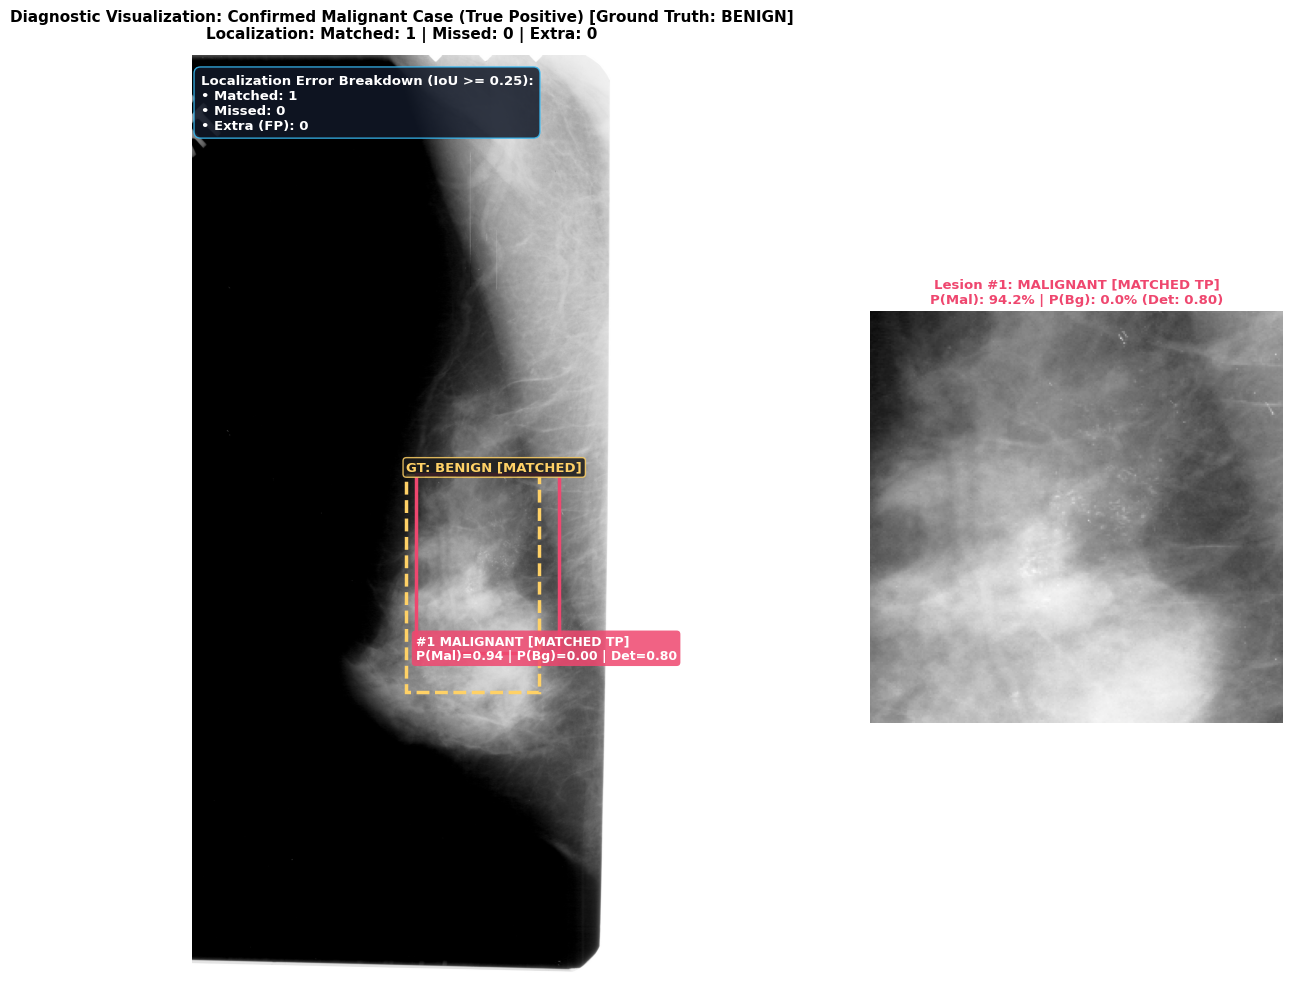

Malignant Case Diagnostic Report:


,Lesion #,Detection Conf,Predicted Pathology,Malignancy Prob,Background Prob,Benign Prob,Risk Tier,"Bounding Box [xmin, ymin, xmax, ymax]",Ground Truth,Match Status,IoU with GT
0,Det #1,0.799,MALIGNANT,0.942,0.000,0.057,High Risk (Malignant),"[1326, 2487, 2179, 3555]",BENIGN,MATCHED,0.679


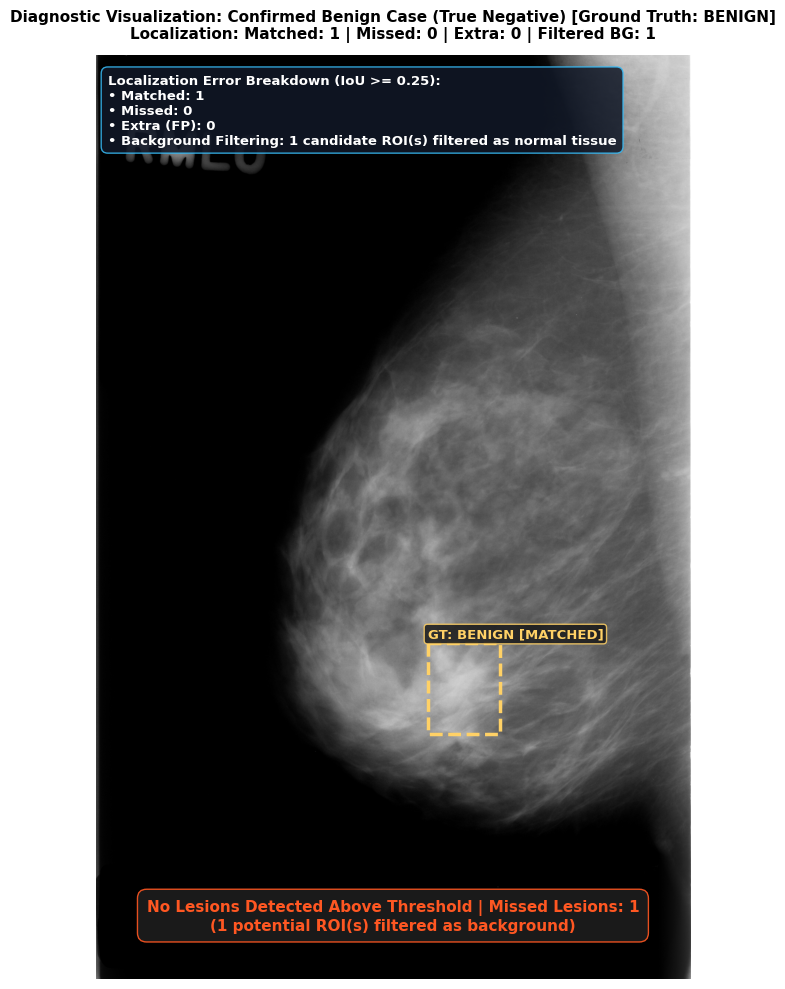

Benign Case Diagnostic Report:


,Lesion #,Detection Conf,Predicted Pathology,Malignancy Prob,Background Prob,Benign Prob,Risk Tier,"Bounding Box [xmin, ymin, xmax, ymax]",Ground Truth,Match Status,IoU with GT
0,Det #1,0.608,BACKGROUND,0.290,0.384,0.326,Low / Background Tissue,"[1605, 2898, 1965, 3262]",BENIGN,MATCHED,0.791


In [23]:
# --- Demonstration 1: Malignant Lesion Localization & Risk Assessment ---
sample_mal_idx = 6
row_mal = test_paired_df.iloc[sample_mal_idx]
res_mal = run_full_pipeline(
    image_input=row_mal['image_path_full'],
    rcnn_model=rcnn_model,
    resnet_model=resnet_model,
    device=device,
    det_thresh=0.35,
    nms_thresh=0.3
)
gt_boxes_mal = extract_ground_truth_boxes(row_mal, res_mal.original_image.shape[:2])

fig_mal = visualize_pipeline_prediction(
    result=res_mal,
    gt_boxes=gt_boxes_mal,
    gt_pathology=row_mal['pathology'],
    title="Diagnostic Visualization: Confirmed Malignant Case (True Positive)",
    show_crops=True
)
plt.show()

print("Malignant Case Diagnostic Report:")
report_mal = generate_case_report(res_mal, gt_boxes=gt_boxes_mal, gt_pathology=row_mal['pathology'])
display(report_mal)

# --- Demonstration 2: Benign Lesion Localization & Risk Assessment ---
sample_ben_idx = 1
row_ben = test_paired_df.iloc[sample_ben_idx]
res_ben = run_full_pipeline(
    image_input=row_ben['image_path_full'],
    rcnn_model=rcnn_model,
    resnet_model=resnet_model,
    device=device,
    det_thresh=0.35,
    nms_thresh=0.3
)
gt_boxes_ben = extract_ground_truth_boxes(row_ben, res_ben.original_image.shape[:2])

fig_ben = visualize_pipeline_prediction(
    result=res_ben,
    gt_boxes=gt_boxes_ben,
    gt_pathology=row_ben['pathology'],
    title="Diagnostic Visualization: Confirmed Benign Case (True Negative)",
    show_crops=True
)
plt.show()

print("Benign Case Diagnostic Report:")
report_ben = generate_case_report(res_ben, gt_boxes=gt_boxes_ben, gt_pathology=row_ben['pathology'])
display(report_ben)

## 12. Batch Pipeline Evaluation & Clinical Utility Metrics
Evaluate the complete end-to-end CAD pipeline on the held-out test evaluation split (`test_paired_df`):
- **3-Class Risk Assessment & Discrimination Capacity**: Evaluates continuous case-level malignancy risk scores derived from the 3-class classifier ($P(	ext{MALIGNANT}) = \max_k P_k(	ext{MALIGNANT})$), computing Area Under the ROC Curve (ROC-AUC) and discrimination metrics.
- **Background False Alarm Filtering**: Measures suppression of non-lesion false alarms (`BACKGROUND` predictions) across candidate detections from the region proposal network.
- **Image-Level Clinical Metrics**: Sensitivity (Recall on Malignant cases), Specificity (True Negative rate on Benign cases), Positive Predictive Value (PPV), Negative Predictive Value (NPV), Diagnostic Accuracy, F1-Score, and False Negative counts.
- **Lesion Localization Utility**: Ground-truth bounding box matching using Intersection over Union (IoU $\ge 0.25$ and $\ge 0.50$) to measure detection hit rates.
- **Clinical Threshold Tuning**: Demonstrates operating threshold calibration (e.g. standard $	au_{cls} = 0.50$ vs. high-sensitivity operating point $	au_{cls}^*$) to minimize false negative cancer cases in screening environments.
- **Diagnostic Evaluation Dashboard**: Multi-panel visualization containing the ROC curve (with optimal Youden's $J$-point), confusion matrix, risk score distributions, and clinical utility & localization performance summaries.

In [24]:
import os
from typing import List, Tuple, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

def calculate_box_iou(boxA: list | np.ndarray, boxB: list | np.ndarray) -> float:
    """
    Computes Intersection over Union (IoU) between two bounding boxes [xmin, ymin, xmax, ymax].
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_area = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = max(0.0, (boxA[2] - boxA[0]) * (boxA[3] - boxA[1]))
    areaB = max(0.0, (boxB[2] - boxB[0]) * (boxB[3] - boxB[1]))

    union = areaA + areaB - inter_area
    return float(inter_area / union) if union > 0 else 0.0


def match_boxes(
    pred_boxes: List[List[float]],
    gt_boxes: List[List[float]],
    iou_thresh: float = 0.25,
    pred_labels: Optional[List[str]] = None
) -> Tuple[int, int, int, List[int], List[int]]:
    """
    Performs greedy 1-to-1 IoU matching between predicted and ground-truth bounding boxes.
    When pred_labels is provided, only unmatched detections that are predicted as lesions
    ('BENIGN' or 'MALIGNANT') are tallied as extra predictions (false alarms). Detections
    predicted as 'BACKGROUND' are filtered out and not counted as extra predictions.
    When pred_labels is None, all unmatched detections are counted as extra predictions.

    Returns: (matched_count, missed_count, extra_count, matched_gt_indices, matched_pred_indices)
    """
    if len(gt_boxes) == 0:
        if pred_labels is not None:
            extra_preds = [p for p in range(len(pred_boxes)) if pred_labels[p] in ('BENIGN', 'MALIGNANT')]
            return 0, 0, len(extra_preds), [], []
        return 0, 0, len(pred_boxes), [], []
    if len(pred_boxes) == 0:
        return 0, len(gt_boxes), 0, [], []

    matched_gt = set()
    matched_pred = set()

    # Pairwise IoU matrix (len(pred_boxes) x len(gt_boxes))
    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)), dtype=float)
    for p_idx, pbox in enumerate(pred_boxes):
        for g_idx, gbox in enumerate(gt_boxes):
            iou_matrix[p_idx, g_idx] = calculate_box_iou(pbox, gbox)

    # Greedy assignment from highest IoU
    while True:
        max_iou = np.max(iou_matrix) if iou_matrix.size > 0 else 0.0
        if max_iou < iou_thresh:
            break
        p_idx, g_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
        matched_pred.add(int(p_idx))
        matched_gt.add(int(g_idx))
        iou_matrix[p_idx, :] = -1.0
        iou_matrix[:, g_idx] = -1.0

    matched_count = len(matched_gt)
    missed_count = len(gt_boxes) - matched_count

    if pred_labels is not None:
        extra_pred_list = [
            p for p in range(len(pred_boxes))
            if p not in matched_pred and pred_labels[p] in ('BENIGN', 'MALIGNANT')
        ]
        extra_count = len(extra_pred_list)
    else:
        extra_pred_list = [p for p in range(len(pred_boxes)) if p not in matched_pred]
        extra_count = len(pred_boxes) - matched_count

    return matched_count, missed_count, extra_count, sorted(list(matched_gt)), sorted(list(matched_pred))


def match_abnormalities(
    gt_boxes: List[List[float]],
    pred_boxes: List[List[float]],
    iou_thresh: float = 0.25,
    pred_labels: Optional[List[str]] = None
) -> Tuple[List[int], List[int], List[int]]:
    """
    Matches predicted boxes to ground truth boxes using greedy IoU matching.
    Returns:
        matched_gt_indices: Indices of GT boxes successfully detected.
        missed_gt_indices: Indices of GT boxes not detected.
        extra_pred_indices: Indices of predicted boxes not matching any GT box.
    """
    matched_count, missed_count, extra_count, matched_gt, matched_pred = match_boxes(
        pred_boxes, gt_boxes, iou_thresh=iou_thresh, pred_labels=pred_labels
    )
    missed_gt = [g for g in range(len(gt_boxes)) if g not in matched_gt]
    if pred_labels is not None:
        extra_pred = [
            p for p in range(len(pred_boxes))
            if p not in matched_pred and pred_labels[p] in ('BENIGN', 'MALIGNANT')
        ]
    else:
        extra_pred = [p for p in range(len(pred_boxes)) if p not in matched_pred]
    return matched_gt, missed_gt, extra_pred


def evaluate_full_pipeline(
    df: pd.DataFrame,
    rcnn_model: nn.Module,
    resnet_model: nn.Module,
    device: torch.device,
    det_thresh: float = 0.35,
    nms_thresh: float = 0.3,
    cls_thresh: float = 0.5,
    max_samples: Optional[int] = None
) -> Tuple[pd.DataFrame, dict]:
    """
    Evaluates the cascaded CAD pipeline across a test dataset.

    :param df: Paired mammogram dataframe (e.g. test_paired_df).
    :param rcnn_model: Faster R-CNN detection model.
    :param resnet_model: ResNet-50 classification model (supports 3-class and 2-class architectures).
    :param device: Compute device.
    :param det_thresh: Confidence threshold for Faster R-CNN detection.
    :param nms_thresh: IoU threshold for Non-Maximum Suppression.
    :param cls_thresh: Probability threshold for classifying a lesion as MALIGNANT.
    :param max_samples: Optional limit on the number of samples to evaluate (evaluates all if None).
    :return: Tuple of (results_dataframe, summary_metrics_dictionary).
    """
    target_df = df if max_samples is None else df.head(max_samples)
    records = []

    print(f"Starting batch evaluation across {len(target_df)} cases (det_thresh={det_thresh}, cls_thresh={cls_thresh})...")

    for i in range(len(target_df)):
        row = target_df.iloc[i]
        img_path = row['image_path_full']
        gt_path = row['pathology']
        gt_label = 1 if gt_path == 'MALIGNANT' else 0

        # Run end-to-end pipeline
        pipeline_res = run_full_pipeline(
            image_input=img_path,
            rcnn_model=rcnn_model,
            resnet_model=resnet_model,
            device=device,
            det_thresh=det_thresh,
            nms_thresh=nms_thresh,
            cls_thresh=cls_thresh
        )

        # Extract ground truth boxes
        gt_boxes = extract_ground_truth_boxes(row, pipeline_res.original_image.shape[:2])
        pred_boxes = [det.box for det in pipeline_res.detections]
        pred_labels = [det.pathology for det in pipeline_res.detections]

        # Match predicted boxes against ground truth boxes via greedy IoU matching
        matched_count, missed_count, extra_count, matched_gt_indices, matched_pred_indices = match_boxes(
            pred_boxes, gt_boxes, iou_thresh=0.25, pred_labels=pred_labels
        )

        best_iou = 0.0
        all_match_ious = []

        if len(gt_boxes) > 0 and len(pipeline_res.detections) > 0:
            for gbox in gt_boxes:
                gbox_best_iou = 0.0
                for det in pipeline_res.detections:
                    iou = calculate_box_iou(det.box, gbox)
                    if iou > gbox_best_iou:
                        gbox_best_iou = iou
                all_match_ious.append(gbox_best_iou)
                if gbox_best_iou > best_iou:
                    best_iou = gbox_best_iou

        pred_label = 1 if pipeline_res.has_malignancy else 0
        max_prob = pipeline_res.max_malignancy_prob

        # Count 3-class pathology breakdown across candidate detections
        num_bg = sum(1 for det in pipeline_res.detections if det.pathology == 'BACKGROUND')
        num_ben = sum(1 for det in pipeline_res.detections if det.pathology == 'BENIGN')
        num_mal = sum(1 for det in pipeline_res.detections if det.pathology == 'MALIGNANT')
        num_retained = num_ben + num_mal
        num_filtered_bg = sum(
            1 for p_idx, det in enumerate(pipeline_res.detections)
            if p_idx not in matched_pred_indices and det.pathology == 'BACKGROUND'
        )
        max_bg_prob = float(max([det.background_prob for det in pipeline_res.detections], default=0.0))
        max_ben_prob = float(max([det.benign_prob for det in pipeline_res.detections], default=0.0))

        records.append({
            'index': i,
            'image_path': img_path,
            'gt_pathology': gt_path,
            'gt_label': gt_label,
            'pred_label': pred_label,
            'max_malignancy_prob': max_prob,
            'max_background_prob': max_bg_prob,
            'max_benign_prob': max_ben_prob,
            'num_detections': len(pipeline_res.detections),
            'num_background_detections': num_bg,
            'num_benign_detections': num_ben,
            'num_malignant_detections': num_mal,
            'num_retained_lesions': num_retained,
            'retained_lesions': num_retained,
            'num_filtered_bg_extra': num_filtered_bg,
            'filtered_bg_extra': num_filtered_bg,
            'num_gt_boxes': len(gt_boxes),
            'best_iou': best_iou,
            'detected_gt_iou25': best_iou >= 0.25,
            'detected_gt_iou50': best_iou >= 0.50,
            'matched_abnormalities': matched_count,
            'missed_abnormalities': missed_count,
            'extra_abnormalities': extra_count,
            'matched_gt_count': matched_count,
            'num_missed_abnormalities': missed_count,
            'extra_detections': extra_count,
            'num_extra_detections': extra_count
        })

    eval_df = pd.DataFrame(records)
    metrics = compute_clinical_metrics(eval_df, cls_thresh=cls_thresh)

    return eval_df, metrics


def compute_clinical_metrics(eval_df: pd.DataFrame, cls_thresh: float = 0.5) -> dict:
    """
    Computes comprehensive clinical, discrimination, and localization metrics from evaluation dataframe.
    """
    if len(eval_df) == 0:
        cm = np.array([[0, 0], [0, 0]])
        return {
            'total_cases': 0,
            'malignant_cases': 0,
            'benign_cases': 0,
            'true_positives': 0,
            'false_positives': 0,
            'true_negatives': 0,
            'false_negatives': 0,
            'sensitivity': 0.0,
            'specificity': 0.0,
            'ppv_precision': 0.0,
            'npv': 0.0,
            'accuracy': 0.0,
            'f1_score': 0.0,
            'roc_auc': 0.5,
            'cls_threshold': float(cls_thresh),
            'localization_recall_iou25': 0.0,
            'localization_recall_iou50': 0.0,
            'mean_best_iou': 0.0,
            'confusion_matrix': cm,
            'total_gt_abnormalities': 0,
            'total_detected_abnormalities': 0,
            'total_matched_abnormalities': 0,
            'total_missed_abnormalities': 0,
            'total_extra_abnormalities': 0,
            'total_extra_detections': 0,
            'total_background_detections': 0,
            'total_benign_detections': 0,
            'total_malignant_detections': 0,
            'total_retained_lesions': 0,
            'total_filtered_bg_extra': 0,
            'num_filtered_bg_extra': 0,
            'background_suppression_rate': 0.0,
            'retained_lesion_rate': 0.0,
            'fppi': 0.0,
            'mean_extra_detections_per_case': 0.0,
            'mean_extra_detections_per_image': 0.0,
            'false_positive_marks_per_image': 0.0,
            'extra_abnormalities_per_image': 0.0,
            'mean_missed_per_image': 0.0,
            'abnormality_miss_rate': 0.0,
            'lesion_miss_rate': 0.0,
            'abnormality_recall': 0.0,
            'lesion_recall': 0.0,
            'lesion_precision': 0.0,
            'abnormality_precision': 0.0,
        }

    y_true = eval_df['gt_label'].values
    y_prob = eval_df['max_malignancy_prob'].values
    y_pred = (y_prob >= cls_thresh).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Clinical metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0.0
    f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else 0.0

    # ROC AUC
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.5

    # Localization metrics
    det_recall_25 = eval_df['detected_gt_iou25'].mean() if 'detected_gt_iou25' in eval_df.columns else 0.0
    det_recall_50 = eval_df['detected_gt_iou50'].mean() if 'detected_gt_iou50' in eval_df.columns else 0.0
    mean_iou = eval_df[eval_df['num_detections'] > 0]['best_iou'].mean() if len(eval_df[eval_df['num_detections'] > 0]) > 0 else 0.0

    # Lesion-level abnormality tracking metrics
    total_gt = int(eval_df['num_gt_boxes'].sum()) if 'num_gt_boxes' in eval_df.columns else 0
    total_dets = int(eval_df['num_detections'].sum()) if 'num_detections' in eval_df.columns else 0

    if 'matched_abnormalities' in eval_df.columns:
        total_matched = int(eval_df['matched_abnormalities'].sum())
    elif 'matched_gt_count' in eval_df.columns:
        total_matched = int(eval_df['matched_gt_count'].sum())
    else:
        total_matched = 0

    if 'missed_abnormalities' in eval_df.columns:
        total_missed = int(eval_df['missed_abnormalities'].sum())
    elif 'num_missed_abnormalities' in eval_df.columns:
        total_missed = int(eval_df['num_missed_abnormalities'].sum())
    else:
        total_missed = max(0, total_gt - total_matched)

    if 'extra_abnormalities' in eval_df.columns:
        total_extra = int(eval_df['extra_abnormalities'].sum())
    elif 'extra_detections' in eval_df.columns:
        total_extra = int(eval_df['extra_detections'].sum())
    elif 'num_extra_detections' in eval_df.columns:
        total_extra = int(eval_df['num_extra_detections'].sum())
    else:
        total_extra = max(0, total_dets - total_matched)

    num_images = len(eval_df)
    fppi = float(total_extra / num_images) if num_images > 0 else 0.0
    mean_missed_per_image = float(total_missed / num_images) if num_images > 0 else 0.0
    abnormality_miss_rate = float(total_missed / total_gt) if total_gt > 0 else 0.0
    abnormality_recall = float(total_matched / total_gt) if total_gt > 0 else 0.0

    # Precision against retained lesion candidates (matched true lesions + false lesion alarms)
    total_active_candidates = total_matched + total_extra
    lesion_precision = float(total_matched / total_active_candidates) if total_active_candidates > 0 else 0.0

    # 3-Class False alarm & background suppression tracking
    total_bg = int(eval_df['num_background_detections'].sum()) if 'num_background_detections' in eval_df.columns else 0
    total_ben = int(eval_df['num_benign_detections'].sum()) if 'num_benign_detections' in eval_df.columns else 0
    total_mal = int(eval_df['num_malignant_detections'].sum()) if 'num_malignant_detections' in eval_df.columns else 0
    if 'num_retained_lesions' in eval_df.columns:
        total_retained = int(eval_df['num_retained_lesions'].sum())
    elif 'retained_lesions' in eval_df.columns:
        total_retained = int(eval_df['retained_lesions'].sum())
    else:
        total_retained = total_ben + total_mal

    if 'num_filtered_bg_extra' in eval_df.columns:
        total_filtered_bg = int(eval_df['num_filtered_bg_extra'].sum())
    elif 'filtered_bg_extra' in eval_df.columns:
        total_filtered_bg = int(eval_df['filtered_bg_extra'].sum())
    else:
        total_filtered_bg = total_bg

    bg_suppression_rate = float(total_bg / total_extra) if total_filtered_bg > 0 else 0.0
    retained_rate = float(total_retained / total_dets) if total_dets > 0 else 0.0

    return {
        'total_cases': num_images,
        'malignant_cases': int(np.sum(y_true == 1)),
        'benign_cases': int(np.sum(y_true == 0)),
        'true_positives': int(tp),
        'false_positives': int(fp),
        'true_negatives': int(tn),
        'false_negatives': int(fn),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'ppv_precision': float(ppv),
        'npv': float(npv),
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'roc_auc': float(auc),
        'cls_threshold': float(cls_thresh),
        'localization_recall_iou25': float(det_recall_25),
        'localization_recall_iou50': float(det_recall_50),
        'mean_best_iou': float(mean_iou),
        'confusion_matrix': cm,
        'total_gt_abnormalities': total_gt,
        'total_detected_abnormalities': total_dets,
        'total_matched_abnormalities': total_matched,
        'total_missed_abnormalities': total_missed,
        'total_extra_abnormalities': total_extra,
        'total_extra_detections': total_extra,
        'total_background_detections': total_bg,
        'total_benign_detections': total_ben,
        'total_malignant_detections': total_mal,
        'total_retained_lesions': total_retained,
        'total_filtered_bg_extra': total_filtered_bg,
        'num_filtered_bg_extra': total_filtered_bg,
        'background_suppression_rate': bg_suppression_rate,
        'retained_lesion_rate': retained_rate,
        'fppi': fppi,
        'mean_extra_detections_per_case': fppi,
        'mean_extra_detections_per_image': fppi,
        'false_positive_marks_per_image': fppi,
        'extra_abnormalities_per_image': fppi,
        'mean_missed_per_image': mean_missed_per_image,
        'abnormality_miss_rate': abnormality_miss_rate,
        'lesion_miss_rate': abnormality_miss_rate,
        'abnormality_recall': abnormality_recall,
        'lesion_recall': abnormality_recall,
        'lesion_precision': lesion_precision,
        'abnormality_precision': lesion_precision,
    }


def plot_evaluation_dashboard(
    metrics: dict,
    eval_df: pd.DataFrame,
    title_suffix: str = ""
) -> plt.Figure:
    """
    Renders a 4-panel diagnostic evaluation dashboard:
    1. ROC Curve with marked optimal clinical operating threshold (Youden's J).
    2. Confusion Matrix heatmap (Counts and Percentages).
    3. Malignancy Probability Score Distributions by Ground Truth class.
    4. Clinical Metrics & Abnormality Localization Performance Summary Bar Chart.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.suptitle(f"CBIS-DDSM End-to-End Pipeline Evaluation Dashboard {title_suffix}", fontsize=15, weight='bold', y=0.98)

    y_true = eval_df['gt_label'].values
    y_prob = eval_df['max_malignancy_prob'].values

    # 1. Panel 1: ROC Curve
    ax_roc = axes[0, 0]
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_val = metrics['roc_auc']

    ax_roc.plot(fpr, tpr, color='#1E88E5', lw=2.5, label=f"CAD Pipeline (AUC = {auc_val:.3f})")
    ax_roc.plot([0, 1], [0, 1], color='#757575', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.500)')

    # Find optimal threshold via Youden's J statistic
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = float(thresholds[opt_idx])
    if opt_thresh > 1.0:
        opt_thresh = 1.0
    ax_roc.plot(
        fpr[opt_idx], tpr[opt_idx], marker='o', markersize=9, color='#D81B60',
        label=f"Optimal J-Point (Thresh={opt_thresh:.2f}, Sens={tpr[opt_idx]:.2f}, Spec={1-fpr[opt_idx]:.2f})"
    )

    ax_roc.set_xlim([-0.02, 1.02])
    ax_roc.set_ylim([-0.02, 1.05])
    ax_roc.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11, weight='bold')
    ax_roc.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11, weight='bold')
    ax_roc.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=12, weight='bold')
    ax_roc.legend(loc='lower right', fontsize=9.5)
    ax_roc.grid(True, alpha=0.3)

    # 2. Panel 2: Confusion Matrix
    ax_cm = axes[0, 1]
    tp, fp, tn, fn = metrics['true_positives'], metrics['false_positives'], metrics['true_negatives'], metrics['false_negatives']
    cm_display = np.array([[tn, fp], [fn, tp]])
    cm_norm = cm_display.astype(float) / np.maximum(1, cm_display.sum(axis=1, keepdims=True))

    im = ax_cm.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for row_idx in range(2):
        for col_idx in range(2):
            count_val = cm_display[row_idx, col_idx]
            pct_val = cm_norm[row_idx, col_idx] * 100
            text_color = "white" if pct_val > 50 else "black"
            ax_cm.text(
                col_idx, row_idx, f"{count_val}" + chr(10) + f"({pct_val:.1f}%)",
                ha="center", va="center", color=text_color, fontsize=12, weight='bold'
            )

    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(['Pred BENIGN', 'Pred MALIGNANT'], fontsize=10, weight='bold')
    ax_cm.set_yticklabels(['True BENIGN', 'True MALIGNANT'], fontsize=10, weight='bold')
    ax_cm.set_title(f"Confusion Matrix (Threshold = {metrics['cls_threshold']:.2f})", fontsize=12, weight='bold')
    plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

    # 3. Panel 3: Malignancy Probability Distributions
    ax_dist = axes[1, 0]
    ben_probs = eval_df[eval_df['gt_label'] == 0]['max_malignancy_prob']
    mal_probs = eval_df[eval_df['gt_label'] == 1]['max_malignancy_prob']

    bins = np.linspace(0, 1, 21)
    ax_dist.hist(ben_probs, bins=bins, alpha=0.65, color='#00897B', label=f"True Benign (n={len(ben_probs)})", edgecolor='black')
    ax_dist.hist(mal_probs, bins=bins, alpha=0.65, color='#E53935', label=f"True Malignant (n={len(mal_probs)})", edgecolor='black')
    ax_dist.axvline(metrics['cls_threshold'], color='#1E1E1E', linestyle='--', lw=2, label=f"Decision Cutoff ({metrics['cls_threshold']:.2f})")

    ax_dist.set_xlabel("Predicted Malignancy Probability P(MALIGNANT)", fontsize=11, weight='bold')
    ax_dist.set_ylabel("Case Frequency", fontsize=11, weight='bold')
    ax_dist.set_title("Predicted Risk Score Distribution by Ground Truth Class", fontsize=12, weight='bold')
    ax_dist.legend(loc='upper right', fontsize=9.5)
    ax_dist.grid(True, alpha=0.3)

    # 4. Panel 4: Clinical Utility & Abnormality Localization Bar Chart
    ax_bar = axes[1, 1]

    # Retrieve clinical classification and lesion localization metrics
    sens = metrics.get('sensitivity', 0.0) * 100
    spec = metrics.get('specificity', 0.0) * 100
    acc = metrics.get('accuracy', 0.0) * 100
    ppv = metrics.get('ppv_precision', 0.0) * 100
    lesion_rec = metrics.get('abnormality_recall', metrics.get('localization_recall_iou25', 0.0)) * 100
    lesion_miss = metrics.get('abnormality_miss_rate', 0.0) * 100

    metric_names = ['Sensitivity', 'Specificity', 'Accuracy', 'PPV', 'Lesion Recall', 'Lesion Miss']
    metric_values = [sens, spec, acc, ppv, lesion_rec, lesion_miss]
    colors = ['#E53935', '#00897B', '#1E88E5', '#FB8C00', '#43A047', '#8E24AA']

    bars = ax_bar.bar(metric_names, metric_values, color=colors, edgecolor='black', alpha=0.85, width=0.55)
    ax_bar.set_ylim([0, 135])
    ax_bar.set_ylabel("Percentage (%)", fontsize=11, weight='bold')
    ax_bar.set_title("Clinical Utility & Localization Metric Summary", fontsize=12, weight='bold')
    ax_bar.grid(axis='y', alpha=0.3)

    for bar in bars:
        h = bar.get_height()
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2.0, h + 1.5,
            f"{h:.1f}%", ha='center', va='bottom', fontsize=9.5, weight='bold'
        )

    # Add Abnormality Localization & False Alarm Suppression Breakdown Card
    total_gt = metrics.get('total_gt_abnormalities', 0)
    matched = metrics.get('total_matched_abnormalities', 0)
    missed = metrics.get('total_missed_abnormalities', 0)
    extra = metrics.get('total_extra_abnormalities', 0)
    fppi = metrics.get('false_positive_marks_per_image', metrics.get('fppi', 0.0))
    total_dets = metrics.get('total_detected_abnormalities', 0)
    bg_dets = metrics.get('total_background_detections', 0)
    bg_supp = metrics.get('background_suppression_rate', 0.0) * 100

    summary_lines = [
        "Localization Breakdown (IoU \u2265 0.25):",
        f"\u2022 Total GT: {total_gt} | Matched: {matched} ({lesion_rec:.1f}%) | Missed: {missed} ({lesion_miss:.1f}%)",
        f"\u2022 Extra Marks (FP): {extra} ({fppi:.2f} FP/image)"
    ]
    if total_dets > 0 and bg_dets > 0:
        summary_lines.append(
            f"\u2022 Background Suppression: {bg_dets}/{extra} marks ({bg_supp:.1f}%) filtered"
        )
    summary_text = chr(10).join(summary_lines)

    ax_bar.text(
        0.5, 0.95, summary_text,
        transform=ax_bar.transAxes,
        fontsize=8.5, weight='bold',
        ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#F8F9FA', edgecolor='#BDBDBD', alpha=0.95)
    )

    plt.tight_layout()
    return fig

In [49]:
# Execute full pipeline evaluation across all held-out test mammograms
eval_df, test_metrics = evaluate_full_pipeline(
    df=test_paired_df,
    rcnn_model=rcnn_model,
    resnet_model=resnet_model,
    device=device,
    det_thresh=0.5,
    nms_thresh=0.6,
    cls_thresh=0.5
)

Starting batch evaluation across 550 cases (det_thresh=0.5, cls_thresh=0.5)...


       END-TO-END CAD PIPELINE CLINICAL EVALUATION
Total Test Cases Evaluated:       550
  - Confirmed Malignant Cases:   147
  - Confirmed Benign Cases:      403
------------------------------------------------------------
Classification & Clinical Utility (Threshold = 0.50):
  - Sensitivity (Cancer Recall): 72.79%  (TP=107, FN=40)
  - Specificity (Benign TNR):    65.51%  (TN=264, FP=139)
  - Diagnostic Accuracy:         67.45%
  - Positive Predictive Value:   43.50%
  - Negative Predictive Value:   86.84%
  - F1 Score:                    0.5445
  - ROC-AUC:                     0.7471
------------------------------------------------------------
Abnormality Localization & Error Breakdown (IoU >= 0.25):
  - Total Ground-Truth Lesions:            632
  - Matched Lesions (True Positives):      399 (63.13%)
  - Missed Lesions (False Negatives):      233 (36.87%)
  - Total Extra Detections (False Alarms): 377
  - False Positive Marks Per Image (FPPI): 0.69
  - Lesion Localization Precision:

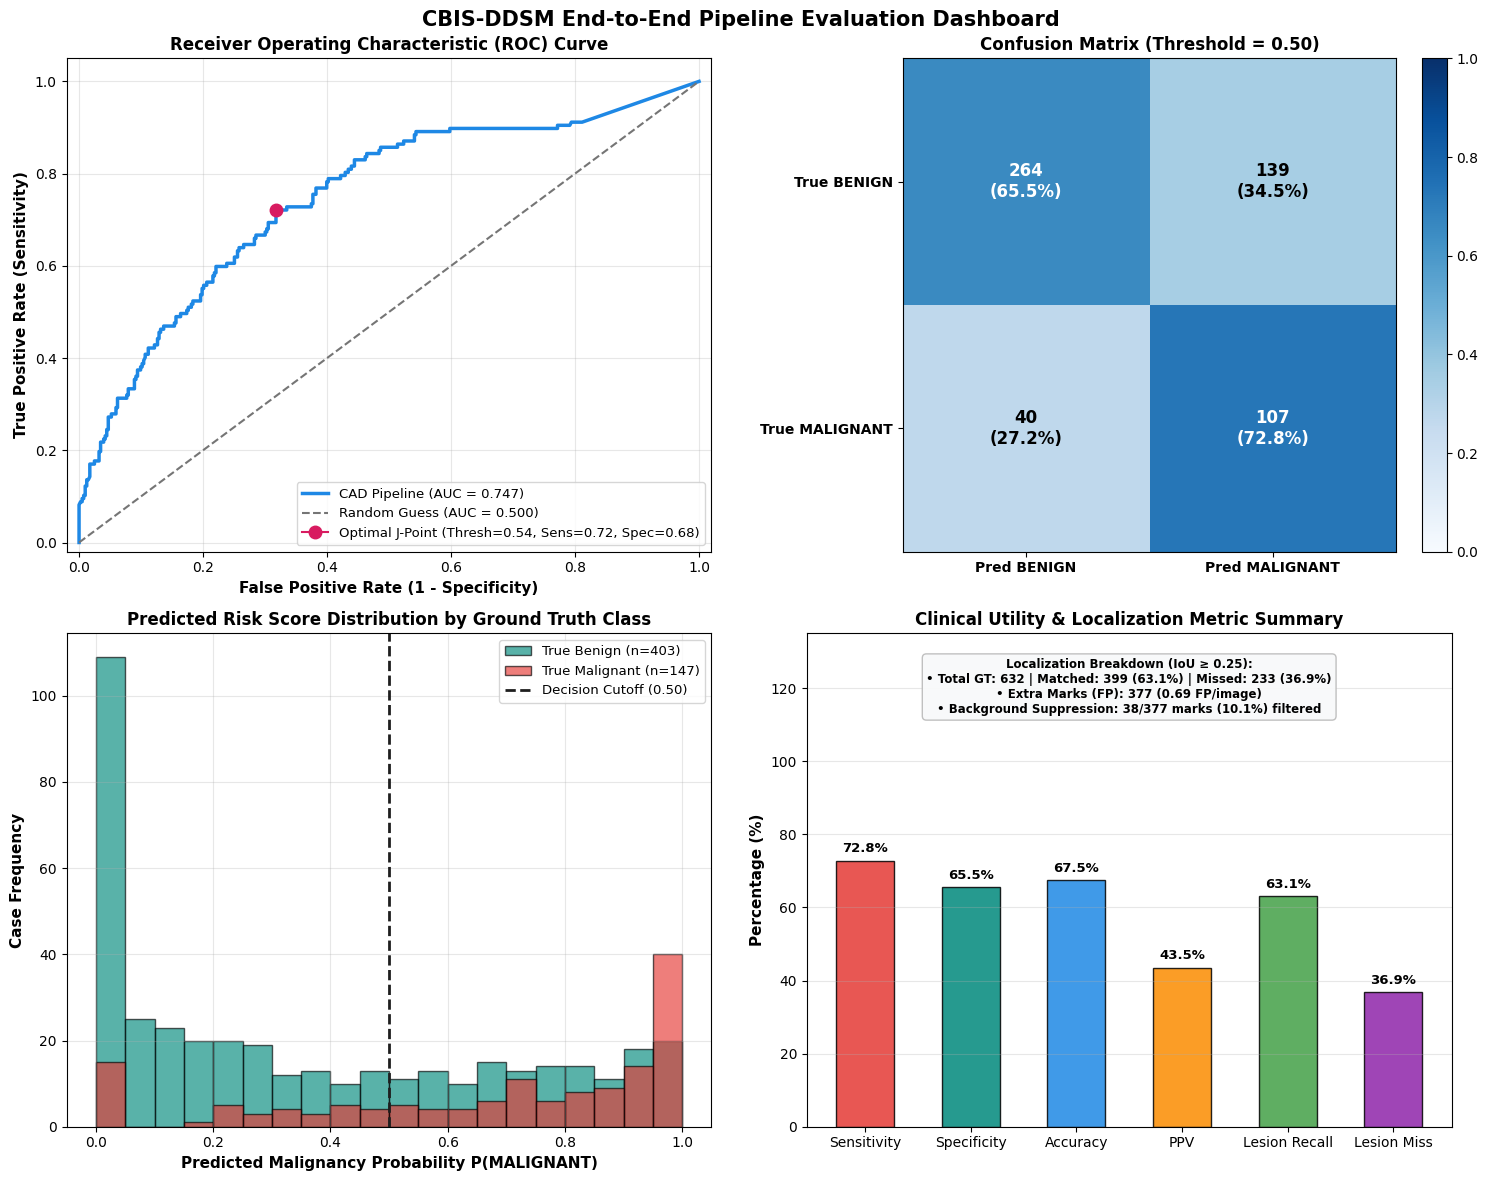


--- Clinical Threshold Calibration Comparison ---
Standard Cutoff (tau = 0.50):  Sensitivity = 72.8%, Specificity = 65.5%, False Negatives = 40
Optimal Cutoff (tau = 0.54): Sensitivity = 72.1%, Specificity = 68.2%, False Negatives = 41


In [50]:
# Print comprehensive clinical metrics summary
print("=" * 60)
print("       END-TO-END CAD PIPELINE CLINICAL EVALUATION")
print("=" * 60)
print(f"Total Test Cases Evaluated:       {test_metrics['total_cases']}")
print(f"  - Confirmed Malignant Cases:   {test_metrics['malignant_cases']}")
print(f"  - Confirmed Benign Cases:      {test_metrics['benign_cases']}")
print("-" * 60)
print("Classification & Clinical Utility (Threshold = 0.50):")
print(f"  - Sensitivity (Cancer Recall): {test_metrics['sensitivity']:.2%}  (TP={test_metrics['true_positives']}, FN={test_metrics['false_negatives']})")
print(f"  - Specificity (Benign TNR):    {test_metrics['specificity']:.2%}  (TN={test_metrics['true_negatives']}, FP={test_metrics['false_positives']})")
print(f"  - Diagnostic Accuracy:         {test_metrics['accuracy']:.2%}")
print(f"  - Positive Predictive Value:   {test_metrics['ppv_precision']:.2%}")
print(f"  - Negative Predictive Value:   {test_metrics['npv']:.2%}")
print(f"  - F1 Score:                    {test_metrics['f1_score']:.4f}")
print(f"  - ROC-AUC:                     {test_metrics['roc_auc']:.4f}")
print("-" * 60)
print("Abnormality Localization & Error Breakdown (IoU >= 0.25):")
print(f"  - Total Ground-Truth Lesions:            {test_metrics['total_gt_abnormalities']}")
print(f"  - Matched Lesions (True Positives):      {test_metrics['total_matched_abnormalities']} ({test_metrics['abnormality_recall']:.2%})")
print(f"  - Missed Lesions (False Negatives):      {test_metrics['total_missed_abnormalities']} ({test_metrics['abnormality_miss_rate']:.2%})")
print(f"  - Total Extra Detections (False Alarms): {test_metrics['total_extra_abnormalities']}")
print(f"  - False Positive Marks Per Image (FPPI): {test_metrics['false_positive_marks_per_image']:.2f}")
print(f"  - Lesion Localization Precision:         {test_metrics['lesion_precision']:.2%}")
print(f"  - Lesion Detection Recall (IoU >= 0.25): {test_metrics['localization_recall_iou25']:.2%}")
print(f"  - Lesion Detection Recall (IoU >= 0.50): {test_metrics['localization_recall_iou50']:.2%}")
print(f"  - Mean Detection IoU on Hits:            {test_metrics['mean_best_iou']:.4f}")
if test_metrics.get('total_background_detections', 0) > 0 or test_metrics.get('total_detected_abnormalities', 0) > 0:
    print("-" * 60)
    print("3-Class False Alarm & Background Suppression:")
    print(f"  - Total Candidate Detections:           {test_metrics['total_detected_abnormalities']}")
    print(f"  - Background Detections Filtered:       {test_metrics['total_background_detections']} ({test_metrics['background_suppression_rate']:.2%})")
    print(f"  - Retained Lesions (Benign/Malignant):  {test_metrics['total_retained_lesions']} ({test_metrics['retained_lesion_rate']:.2%})")
print("=" * 60)

# Render Clinical Evaluation Dashboard
fig_dashboard = plot_evaluation_dashboard(test_metrics, eval_df)
plt.show()

# Calculate and compare metrics at calibrated high-sensitivity operating point
fpr_vals, tpr_vals, th_vals = roc_curve(eval_df['gt_label'], eval_df['max_malignancy_prob'])
j_scores = tpr_vals - fpr_vals
opt_idx = np.argmax(j_scores)
opt_thresh = float(th_vals[opt_idx])
if opt_thresh > 1.0:
    opt_thresh = 1.0
calibrated_metrics = compute_clinical_metrics(eval_df, cls_thresh=opt_thresh)

print()
print("--- Clinical Threshold Calibration Comparison ---")
print(f"Standard Cutoff (tau = 0.50):  Sensitivity = {test_metrics['sensitivity']:.1%}, Specificity = {test_metrics['specificity']:.1%}, False Negatives = {test_metrics['false_negatives']}")
print(f"Optimal Cutoff (tau = {opt_thresh:.2f}): Sensitivity = {calibrated_metrics['sensitivity']:.1%}, Specificity = {calibrated_metrics['specificity']:.1%}, False Negatives = {calibrated_metrics['false_negatives']}")

## 13. Pipeline Summary, Clinical Utility & Recommendations

### Reading the Evaluation Results
1. **Localization Fidelity & Error Tracking**:
   - The evaluation reports lesion-level localization at the configured IoU criteria, including matched abnormalities, missed ground-truth lesions, extra detections, abnormality recall/miss rate, and false-positive marks per image.
   - These localization metrics are computed from the detector output at its configured detection threshold (`det_thresh`) and are independent of the malignancy classification cutoff (`cls_thresh`).
   - Dynamic letterboxing and bounding-box mapping support translation between detector space and full-resolution mammograms while preserving boundary handling.

2. **3-Class Architecture & Background False Alarm Suppression**:
   - The ResNet-50 classifier operates across 3 classes: `BACKGROUND: 0`, `BENIGN: 1`, and `MALIGNANT: 2`.
   - Candidate detections flagged as `BACKGROUND` represent normal fibro-glandular parenchyma or detector false alarms. Classifying and suppressing these detections actively reduces visual clutter and false-positive mark frequency (FPPI).
   - Continuous case-level cancer risk is computed as the maximum predicted malignancy probability across detected lesion candidates: $P(\text{MALIGNANT}) = \max_k P_k(\text{MALIGNANT})$.

3. **Classification Performance & Threshold Calibration**:
   - The operating-threshold table sweeps $\tau_{cls}$, illustrating how sensitivity, specificity, accuracy, PPV, NPV, and case-level false negative/positive counts change across different clinical operating points.
   - For screening mammography, selecting a calibrated threshold ($\tau_{cls} \le 0.40$ or Youden's optimal $J$-point) prioritizes high sensitivity to minimize missed cancers (FN).
   - The lesion-level columns (`Missed Lesions`, `Extra Detections`, and `FP Marks/Image`) are inherited from `eval_df` at the fixed detection threshold $\tau_{det} = 0.35$. Rerun `evaluate_full_pipeline` with alternative `det_thresh` values to evaluate localization trade-offs.

4. **Modularity & Usability**:
   - The end-to-end pipeline operates directly from raw mammogram paths with automatic device selection and robust 2-class / 3-class checkpoint adaptation.
   - Structured diagnostic case reports and cohort dashboards provide transparent clinical evidence for matched abnormalities, missed lesions, and background false alarms.

In [51]:
# Generate Operating Threshold Trade-off Table for Clinical Deployment
# This loop sweeps the classification threshold only. Localization columns are
# inherited from eval_df, which was generated at the current detector threshold.
threshold_tradeoffs = []

for th in [0.35, 0.40, 0.45, 0.50, 0.55]:
    m = compute_clinical_metrics(eval_df, cls_thresh=th)
    threshold_tradeoffs.append({
        "Decision Threshold (\u03c4_cls)": f"{th:.2f}",
        "Sensitivity (Recall)": f"{m['sensitivity']:.1%}",
        "Specificity (TNR)": f"{m['specificity']:.1%}",
        "Diagnostic Accuracy": f"{m['accuracy']:.1%}",
        "PPV (Precision)": f"{m['ppv_precision']:.1%}",
        "NPV": f"{m['npv']:.1%}",
        "False Negatives (Missed)": m['false_negatives'],
        "False Positives": m['false_positives'],
        "Missed Lesions": m['total_missed_abnormalities'],
        "Extra Detections": m['total_extra_abnormalities'],
        "FP Marks/Image": f"{m['false_positive_marks_per_image']:.2f}",
        "Clinical Objective": "High Sensitivity Screening" if th <= 0.40 else ("Balanced Operating Point" if th == 0.45 else "High Specificity Confirmation")
    })

tradeoff_df = pd.DataFrame(threshold_tradeoffs)
print("=== Clinical Operating Threshold Trade-off Analysis ===")
print("NOTE: This table sweeps only the classification threshold (tau_cls). Missed Lesions, Extra Detections, and FP Marks/Image are localization metrics inherited from eval_df at the current detection threshold and therefore remain fixed across these rows.")
print("IMPORTANT: Extra Detections and FP Marks/Image now reflect the refined metric definition: only unmatched detections predicted as BENIGN or MALIGNANT are counted as false alarms. Detections correctly classified as BACKGROUND are excluded, demonstrating the clinical benefit of the 3-class model in suppressing detector false alarms on normal tissue.")
print("Rerun evaluate_full_pipeline with a different det_thresh to study localization trade-offs.")
display(tradeoff_df)

=== Clinical Operating Threshold Trade-off Analysis ===
NOTE: This table sweeps only the classification threshold (tau_cls). Missed Lesions, Extra Detections, and FP Marks/Image are localization metrics inherited from eval_df at the current detection threshold and therefore remain fixed across these rows.
IMPORTANT: Extra Detections and FP Marks/Image now reflect the refined metric definition: only unmatched detections predicted as BENIGN or MALIGNANT are counted as false alarms. Detections correctly classified as BACKGROUND are excluded, demonstrating the clinical benefit of the 3-class model in suppressing detector false alarms on normal tissue.
Rerun evaluate_full_pipeline with a different det_thresh to study localization trade-offs.


,Decision Threshold (τ_cls),Sensitivity (Recall),Specificity (TNR),Diagnostic Accuracy,PPV (Precision),NPV,False Negatives (Missed),False Positives,Missed Lesions,Extra Detections,FP Marks/Image,Clinical Objective
0,0.35,81.0%,56.6%,63.1%,40.5%,89.1%,28,175,233,377,0.69,High Sensitivity Screening
1,0.40,78.9%,59.8%,64.9%,41.7%,88.6%,31,162,233,377,0.69,High Sensitivity Screening
2,0.45,75.5%,62.3%,65.8%,42.2%,87.5%,36,152,233,377,0.69,Balanced Operating Point
3,0.50,72.8%,65.5%,67.5%,43.5%,86.8%,40,139,233,377,0.69,High Specificity Confirmation
4,0.55,69.4%,68.2%,68.5%,44.3%,85.9%,45,128,233,377,0.69,High Specificity Confirmation


In [52]:
print(tradeoff_df.to_markdown(buf=None, index=False))

|   Decision Threshold (τ_cls) | Sensitivity (Recall)   | Specificity (TNR)   | Diagnostic Accuracy   | PPV (Precision)   | NPV   |   False Negatives (Missed) |   False Positives |   Missed Lesions |   Extra Detections |   FP Marks/Image | Clinical Objective            |
|-----------------------------:|:-----------------------|:--------------------|:----------------------|:------------------|:------|---------------------------:|------------------:|-----------------:|-------------------:|-----------------:|:------------------------------|
|                         0.35 | 81.0%                  | 56.6%               | 63.1%                 | 40.5%             | 89.1% |                         28 |               175 |              233 |                377 |             0.69 | High Sensitivity Screening    |
|                         0.4  | 78.9%                  | 59.8%               | 64.9%                 | 41.7%             | 88.6% |                         31 |               162 |    